# H1 and H3 analysis
Run the notebook from top to bottom. The output folder contains the locked tables and figures used in the dissertation.

## Data and reproducibility

This notebook uses repository-relative paths only. To reproduce the results:

1. Clone the repository and open Jupyter from the repository root.
2. Install the dependencies: `pip install -r requirements.txt`
3. Run the notebook from top to bottom (Kernel -> Restart & Run All).

The two input files are larger than the GitHub 100 MB file limit and are hosted
externally. The setup cell downloads them automatically into `data/`; if the
automatic download fails, the links in `README.md` allow them to be downloaded
manually. All tables and figures are written to `outputs/`.


## 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from shapely import wkb
from shapely.geometry import box
from sklearn.cluster import DBSCAN
from IPython.display import Image, display
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 11})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / ".git").exists() or (candidate / "data").is_dir():
            return candidate
    return here


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
OUT = REPO_ROOT / "outputs"
FIGURE_OUTPUTS = OUT / "publication_figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUTS.mkdir(parents=True, exist_ok=True)

PARQUET = DATA_DIR / "2025-12-31-ho-man-chan-brands-2016-2025.parquet"
LAD_BOUNDARIES = DATA_DIR / "LAD_boundaries.geojson"

GDRIVE_FILE_IDS = {
    "2025-12-31-ho-man-chan-brands-2016-2025.parquet": "18m2_5TOgHP68_HpvJaCUkjliCfqpbZOM",
    "LAD_boundaries.geojson": "REPLACE_WITH_GEOJSON_FILE_ID",
}


def ensure_input(path: Path) -> Path:
    if path.exists():
        return path

    file_id = GDRIVE_FILE_IDS.get(path.name, "")
    if file_id and not file_id.startswith("REPLACE_WITH"):
        try:
            import gdown
        except ImportError:
            import subprocess
            import sys
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "--quiet", "gdown"]
            )
            import gdown

        print(f"Downloading {path.name} from Google Drive.")
        try:
            gdown.download(id=file_id, output=str(path), quiet=False)
        except Exception as error:
            print(f"Automatic download failed: {error}")

    if not path.exists():
        raise FileNotFoundError(
            f"Required input file not found: {path}\n"
            "Download it using the link in README.md and place it in the data/ "
            "directory, then re-run this cell."
        )
    return path


ensure_input(PARQUET)
ensure_input(LAD_BOUNDARIES)

BASE = OUT
print("Repository root:", REPO_ROOT)
print("Input panel:    ", PARQUET)
print("LAD boundaries: ", LAD_BOUNDARIES)
print("Outputs:        ", OUT)


Repository root: /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy
Input panel:     /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/data/2025-12-31-ho-man-chan-brands-2016-2025.parquet
LAD boundaries:  /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/data/LAD_boundaries.geojson
Outputs:         /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/outputs


## 2. Research definitions

In [3]:
# Operational event year = year when the brand's physical store estate
# materially exited or was substantially restructured in a way relevant to
# property vacancy. This is deliberately not always the first legal distress
# event.
OPERATIONAL_EVENT_YEAR = {
    "bhs": 2016,
    "toys r us": 2018,
    "maplin": 2018,
    "poundworld": 2018,
    "byron": 2020,
    "thomas cook": 2019,
    "mothercare": 2019,
    "arcadia": 2020,
    "carluccios": 2020,
    "chiquito": 2020,
    "cath kidston": 2020,
    "frankie&bennys": 2020,
    "cafe rouge": 2020,
    "bella italia": 2020,
    "debenhams": 2020,
    "strada": 2018,
    "paperchase": 2023,
    "wilko": 2023,
    "prezzo": 2018,
    "body shop": 2024,
    "ted baker": 2024,
    "homebase": 2024,
}

# All listed brands are excluded from the control pool. Only brands with an event year enter H1/H3.
BRAND_PATTERNS = {
    "arcadia": r"arcadia|topshop|top shop|dorothy perkins|miss selfridge|miss selfrid|wallis\b|outfit stores|outfit fashion|outfit retail",
    "wilko": r"\bwilko\b|wilkinson hardware|wl realisations",
    "poundland": r"\bpoundland\b",
    "debenhams": r"debenhams|department stores realisation",
    "bhs": r"\bbhs\b|british home stores",
    "toys r us": r"toys\s*r\s*us",
    "maplin": r"\bmaplin\b",
    "poundworld": r"\bpoundworld\b",
    "thomas cook": r"thomas cook",
    "mothercare": r"\bmothercare\b",
    "paperchase": r"paperchase|aspen phoenix",
    "homebase": r"\bhomebase\b|\bhhgl\b",
    "body shop": r"body shop",
    "ted baker": r"ted baker|no ordinary designer",
    "cath kidston": r"cath kidston",
    "prezzo": r"\bprezzo\b",
    "byron": r"byron hamburger|byron burger|byron restaurants",
    "carluccios": r"carluccio",
    "strada": r"\bstrada\b|strada trading",
    "pizza hut": r"pizza hut",
    "cafe rouge": r"cafe rouge",
    "bella italia": r"bella italia",
    "las iguanas": r"las iguanas",
    "frankie&bennys": r"frankie",
    "chiquito": r"chiquito",
    "brewdog": r"brewdog",
    "franco manca": r"franco ?manca",
    "black sheep": r"black sheep coffe|conilon",
    "blank street": r"\bblank street\b",
    "wasabi": r"\bwasabi\b",
    "select fashion": r"select fashion|genus uk|selbyect",
}

LOOSE_CONTROL_EXCLUSION = [
    "wilko", "wilkinson", "poundland", "debenhams", "bhs", "british home",
    "toys r us", "maplin", "poundworld", "thomas cook", "mothercare",
    "paperchase", "arcadia", "topshop", "dorothy perkins", "miss selfridge",
    "burton", "homebase", "hhgl", "body shop", "ted baker", "cath kidston",
    "prezzo", "byron", "carluccio", "strada", "pizza hut", "cafe rouge",
    "bella italia", "iguanas", "frankie", "chiquito", "brewdog",
    "franco manca", "black sheep", "blank street", "wasabi", "select",
]

EVENT_MIN = -4
EVENT_MAX = 5
N_CONTROLS = 3
DBSCAN_EPS_METRES = 400
DBSCAN_MIN_SAMPLES = 3
ROBUSTNESS_CONTROL_EXCLUSION_RADII = [100, 150, 400]
SENSITIVITY_EPS = [250, 400, 800]
RANDOM_SEED = 42

## 3. Functions

### Loading

In [4]:
def read_voa() -> pd.DataFrame:
    cols = [
        "period",
        "geocode_name",
        "uarn",
        "account_name",
        "occupation_state",
        "category_subgroup",
        "rateable_value",
        "searchable_address",
        "geometry",
    ]
    df = pd.read_parquet(PARQUET, columns=cols)
    df["year"] = df["period"].astype(str).str[:4].astype(int)
    df["account_lc"] = df["account_name"].fillna("").str.lower()
    return df

### Brand identification

In [5]:
def identify_brand_properties(df: pd.DataFrame) -> tuple[pd.Series, set[int]]:
    brand = pd.Series(index=df.index, dtype="object")
    for name, pattern in BRAND_PATTERNS.items():
        hit = df["account_lc"].str.contains(pattern, regex=True, na=False)
        brand.loc[hit & brand.isna()] = name

    brand_by_uarn = (
        pd.DataFrame({"uarn": df["uarn"], "brand": brand})
        .dropna(subset=["brand"])
        .groupby("uarn")["brand"]
        .first()
    )

    loose_pattern = "|".join(re.escape(x) for x in LOOSE_CONTROL_EXCLUSION)
    tainted = set(df.loc[df["account_lc"].str.contains(loose_pattern, na=False), "uarn"].unique())
    return brand_by_uarn, tainted

### Site construction and DBSCAN

In [6]:
def wkb_to_geometry(hex_value: str):
    if pd.isna(hex_value):
        return None
    try:
        return wkb.loads(bytes.fromhex(hex_value))
    except Exception:
        return None

In [7]:
def make_brand_sites(df: pd.DataFrame, brand_by_uarn: pd.Series) -> gpd.GeoDataFrame:
    first = (
        df[df["uarn"].isin(brand_by_uarn.index)]
        .sort_values(["uarn", "year"])
        .drop_duplicates("uarn")
        .copy()
    )
    first["brand"] = first["uarn"].map(brand_by_uarn)
    first["event_year"] = first["brand"].map(OPERATIONAL_EVENT_YEAR)
    first["geometry_obj"] = first["geometry"].apply(wkb_to_geometry)
    gdf = gpd.GeoDataFrame(first.drop(columns=["geometry"]), geometry="geometry_obj", crs="EPSG:4326")
    gdf = gdf.rename_geometry("geometry")
    gdf = gdf[gdf.geometry.notna()].copy()
    return gdf.to_crs("EPSG:27700")

In [8]:
def assign_dbscan(gdf: gpd.GeoDataFrame, eps: int = DBSCAN_EPS_METRES) -> gpd.GeoDataFrame:
    out = gdf.copy()
    out["cluster_id"] = pd.Series("noise", index=out.index, dtype="object")
    for authority, sub in out.groupby("geocode_name"):
        if len(sub) < DBSCAN_MIN_SAMPLES:
            continue
        coords = np.column_stack([sub.geometry.x, sub.geometry.y])
        labels = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES).fit_predict(coords)
        # Prefix with authority hash to avoid reusing numeric labels across authorities.
        label_series = pd.Series(labels, index=sub.index)
        for raw_label in sorted(set(labels)):
            if raw_label == -1:
                continue
            global_label = f"{authority}_{eps}_{int(raw_label)}"
            out.loc[label_series[label_series == raw_label].index, "cluster_id"] = global_label
    out["clustered"] = out["cluster_id"] != "noise"
    return out

### Control pool and matching

In [9]:
def add_distance_to_clustered_exposure(pool: pd.DataFrame, sites: gpd.GeoDataFrame) -> pd.DataFrame:
    """Distance from each candidate control to the nearest clustered brand site.

    Distances are computed within the same local authority in EPSG:27700 metres.
    They are used for donut robustness checks, not for the main specification.
    """
    out = pool.copy()
    out["geometry_obj"] = out["geometry"].apply(wkb_to_geometry)
    out = out[out["geometry_obj"].notna()].copy()
    out_gdf = gpd.GeoDataFrame(out, geometry="geometry_obj", crs="EPSG:4326").to_crs("EPSG:27700")
    out_gdf["distance_to_clustered_exposure_m"] = np.inf

    clustered_sites = sites[sites["clustered"]].copy()
    for authority, sub in out_gdf.groupby("geocode_name"):
        exposure = clustered_sites[clustered_sites["geocode_name"].eq(authority)]
        if exposure.empty:
            continue
        exposure_xy = np.column_stack([exposure.geometry.x, exposure.geometry.y])
        pool_xy = np.column_stack([sub.geometry.x, sub.geometry.y])
        distances, _ = cKDTree(exposure_xy).query(pool_xy, k=1)
        out_gdf.loc[sub.index, "distance_to_clustered_exposure_m"] = distances

    return pd.DataFrame(out_gdf.drop(columns="geometry"))

In [10]:
def build_control_pool(
    df: pd.DataFrame,
    tainted: set[int],
    sites: gpd.GeoDataFrame | None = None,
    min_distance_from_cluster_m: int | None = None,
) -> pd.DataFrame:
    cols = ["geocode_name", "category_subgroup", "rateable_value"]
    if min_distance_from_cluster_m is not None:
        cols.append("geometry")

    pool = (
        df[~df["uarn"].isin(tainted)]
        .sort_values(["uarn", "year"])
        .groupby("uarn")
        .first()[cols]
        .dropna(subset=["rateable_value"])
    )

    if min_distance_from_cluster_m is not None:
        if sites is None:
            raise ValueError("sites is required for distance-based robustness checks")
        pool = add_distance_to_clustered_exposure(pool, sites)
        pool = pool[pool["distance_to_clustered_exposure_m"] > min_distance_from_cluster_m].copy()

    return pool

In [11]:
def match_controls(
    df: pd.DataFrame,
    brand_by_uarn: pd.Series,
    tainted: set[int],
    sites: gpd.GeoDataFrame | None = None,
    min_distance_from_cluster_m: int | None = None,
    output_prefix: str = "finding",
) -> pd.DataFrame:
    event_uarns = [u for u, b in brand_by_uarn.items() if b in OPERATIONAL_EVENT_YEAR]
    treated = (
        df[df["uarn"].isin(event_uarns)]
        .sort_values(["uarn", "year"])
        .groupby("uarn")
        .first()[["geocode_name", "category_subgroup", "rateable_value"]]
        .dropna(subset=["rateable_value"])
    )
    treated["brand"] = treated.index.map(brand_by_uarn)
    treated["event_year"] = treated["brand"].map(OPERATIONAL_EVENT_YEAR)

    pool = build_control_pool(df, tainted, sites, min_distance_from_cluster_m)

    pool_groups = {
        key: value.sort_values("rateable_value")
        for key, value in pool.groupby(["geocode_name", "category_subgroup"])
    }

    matches = []
    used_controls: set[int] = set()
    for treat_uarn, row in treated.iterrows():
        key = (row["geocode_name"], row["category_subgroup"])
        cand = pool_groups.get(key)
        if cand is None or cand.empty:
            continue
        cand = cand[~cand.index.isin(used_controls)]
        if cand.empty:
            continue
        picked = (cand["rateable_value"] - row["rateable_value"]).abs().nsmallest(N_CONTROLS).index
        used_controls.update(picked)
        for control_uarn in picked:
            matches.append(
                {
                    "treat_uarn": treat_uarn,
                    "control_uarn": control_uarn,
                    "brand": row["brand"],
                    "event_year": int(row["event_year"]),
                    "geocode_name": row["geocode_name"],
                    "category_subgroup": row["category_subgroup"],
                    "treated_rateable_value": row["rateable_value"],
                    "control_rateable_value": pool.loc[control_uarn, "rateable_value"],
                    "control_distance_to_clustered_exposure_m": pool.loc[control_uarn, "distance_to_clustered_exposure_m"]
                    if "distance_to_clustered_exposure_m" in pool.columns else np.nan,
                }
            )

    out = pd.DataFrame(matches)
    out.to_csv(BASE / f"{output_prefix}_control_matches.csv", index=False)
    pd.DataFrame(
        [
            {
                "specification": output_prefix,
                "min_distance_from_cluster_m": min_distance_from_cluster_m
                if min_distance_from_cluster_m is not None else 0,
                "treatment_properties_available": len(treated),
                "eligible_control_pool": len(pool),
                "matched_treated_properties": out["treat_uarn"].nunique() if not out.empty else 0,
                "matched_control_properties": out["control_uarn"].nunique() if not out.empty else 0,
            }
        ]
    ).to_csv(BASE / f"{output_prefix}_control_design_summary.csv", index=False)
    return out

### Event-time vacancy curves

In [12]:
def event_curve(records: pd.DataFrame) -> pd.DataFrame:
    d = records.dropna(subset=["occupation_state"]).copy()
    d = d[(d["t"] >= EVENT_MIN) & (d["t"] <= EVENT_MAX)]
    d["vacant"] = d["occupation_state"].eq("VACANT")
    return d.groupby("t")["vacant"].agg(vacancy_rate="mean", n="count")

In [13]:
def h1_event_study(df: pd.DataFrame, brand_by_uarn: pd.Series, matches: pd.DataFrame) -> pd.DataFrame:
    treated_uarns = matches["treat_uarn"].drop_duplicates()
    treated_meta = matches.drop_duplicates("treat_uarn").set_index("treat_uarn")[["event_year", "brand"]]
    control_meta = matches.drop_duplicates("control_uarn").set_index("control_uarn")[["event_year"]]

    tp = df[df["uarn"].isin(treated_uarns)][["uarn", "year", "occupation_state"]].merge(
        treated_meta, left_on="uarn", right_index=True
    )
    tp["t"] = tp["year"] - tp["event_year"]
    cp = df[df["uarn"].isin(control_meta.index)][["uarn", "year", "occupation_state"]].merge(
        control_meta, left_on="uarn", right_index=True
    )
    cp["t"] = cp["year"] - cp["event_year"]

    tc, cc = event_curve(tp), event_curve(cp)
    curves = pd.DataFrame({
        "treatment_rate": tc["vacancy_rate"], "treatment_n": tc["n"],
        "control_rate": cc["vacancy_rate"], "control_n": cc["n"],
    })
    curves["gap_pp"] = (curves["treatment_rate"] - curves["control_rate"]) * 100
    curves["treatment_pct"] = curves["treatment_rate"] * 100
    curves["control_pct"] = curves["control_rate"] * 100
    curves.to_csv(BASE / "finding_2_h1_event_study_curves.csv")

    pre_gap = curves.loc[EVENT_MIN:-1, "gap_pp"].mean()
    post_gap = curves.loc[0:EVENT_MAX, "gap_pp"].mean()
    summary = pd.DataFrame([{
        "matched_treated_properties": matches["treat_uarn"].nunique(),
        "matched_control_properties": matches["control_uarn"].nunique(),
        "pre_collapse_gap_pp": pre_gap,
        "post_collapse_gap_pp": post_gap,
        "did_style_difference_pp": post_gap - pre_gap,
    }])
    summary.to_csv(BASE / "finding_2_h1_event_study_summary.csv", index=False)

    exposed_colour, control_colour = "#0173B2", "#DE8F05"
    fig, ax = plt.subplots(figsize=(10.8, 6.4))
    ax.plot(curves.index, curves["treatment_pct"], marker="o", ms=6.5, lw=2.7,
            color=exposed_colour)
    ax.plot(curves.index, curves["control_pct"], marker="s", ms=6.0, lw=2.7,
            color=control_colour)
    ax.axvline(0, color="#555555", ls="--", lw=1.2)
    ax.text(0.12, 6.55, "Operational event year", rotation=90, va="bottom",
            ha="left", fontsize=9, color="#555555")

    t0_exposed = curves.loc[0, "treatment_pct"]
    t0_control = curves.loc[0, "control_pct"]
    ax.annotate(f"{t0_exposed:.1f}%", xy=(0, t0_exposed), xytext=(0.55, t0_exposed + 1.3),
                arrowprops={"arrowstyle": "-", "color": exposed_colour, "lw": 0.9},
                fontsize=10, color=exposed_colour, ha="left")
    ax.annotate(f"{t0_control:.1f}%", xy=(0, t0_control), xytext=(0.55, t0_control - 2.0),
                arrowprops={"arrowstyle": "-", "color": control_colour, "lw": 0.9},
                fontsize=10, color=control_colour, ha="left")

    last_t = int(curves.index.max())
    upper, lower = curves.loc[last_t, ["treatment_pct", "control_pct"]]
    ax.annotate("", xy=(last_t, upper), xytext=(last_t, lower),
                arrowprops={"arrowstyle": "<->", "color": "#333333", "lw": 1.2})
    ax.text(last_t - 0.18, (upper + lower) / 2, f"+{upper-lower:.2f} pp",
            ha="right", va="center", fontsize=10, color="#333333",
            bbox={"fc": "white", "ec": "none", "alpha": 0.88, "pad": 1.5})
    ax.text(EVENT_MIN + 0.15, 28.3, f"Pre-event average gap: {pre_gap:+.2f} pp",
            ha="left", va="center", fontsize=10,
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#BBBBBB"})
    ax.text(last_t + 0.10, upper, "Exposed sites", color=exposed_colour,
            va="center", ha="left", fontsize=10.5, weight="semibold")
    ax.text(last_t + 0.10, lower, "Matched controls", color=control_colour,
            va="center", ha="left", fontsize=10.5, weight="semibold")

    ax.set_title("Vacancy trajectories around operational brand collapse", loc="left", pad=14)
    ax.set_xlabel("Years relative to event (t)")
    ax.set_ylabel("Vacancy rate (%)")
    ax.set_xlim(EVENT_MIN - 0.25, EVENT_MAX + 1.05)
    ax.set_ylim(5.8, 31.2)
    ax.grid(axis="y", color="#E2E2E2", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(BASE / "finding_2_h1_event_study.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5.5))
    colours = np.where(curves.index < 0, "#8F9899", "#D55E00")
    ax.bar(curves.index, curves["gap_pp"], color=colours, alpha=0.88)
    ax.axhline(0, color="#333333", lw=0.9)
    ax.axvline(-0.5, color="#777777", ls="--", lw=1.1)
    ax.set_title("Vacancy gap between exposed and matched non-exposed sites", loc="left")
    ax.set_xlabel("Years relative to event (t)")
    ax.set_ylabel("Exposed minus control vacancy (percentage points)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E2E2E2", linewidth=0.7)
    fig.tight_layout()
    fig.savefig(BASE / "finding_2_h1_gap_by_event_time.png", dpi=300, bbox_inches="tight")
    plt.close(fig)
    return curves


In [14]:
def h1_summary_from_matches(df: pd.DataFrame, matches: pd.DataFrame, specification: str) -> dict:
    treated_uarns = matches["treat_uarn"].drop_duplicates()
    treated_meta = matches.drop_duplicates("treat_uarn").set_index("treat_uarn")[["event_year", "brand"]]
    control_meta = matches.drop_duplicates("control_uarn").set_index("control_uarn")[["event_year"]]

    tp = df[df["uarn"].isin(treated_uarns)][["uarn", "year", "occupation_state"]].merge(
        treated_meta, left_on="uarn", right_index=True
    )
    tp["t"] = tp["year"] - tp["event_year"]

    cp = df[df["uarn"].isin(control_meta.index)][["uarn", "year", "occupation_state"]].merge(
        control_meta, left_on="uarn", right_index=True
    )
    cp["t"] = cp["year"] - cp["event_year"]

    tc = event_curve(tp)
    cc = event_curve(cp)
    curves = pd.DataFrame(
        {
            "treatment_rate": tc["vacancy_rate"],
            "treatment_n": tc["n"],
            "control_rate": cc["vacancy_rate"],
            "control_n": cc["n"],
        }
    )
    curves["gap_pp"] = (curves["treatment_rate"] - curves["control_rate"]) * 100
    curves.to_csv(BASE / f"robustness_{specification}_event_curves.csv")

    pre_gap = curves.loc[EVENT_MIN:-1, "gap_pp"].mean()
    post_gap = curves.loc[0:EVENT_MAX, "gap_pp"].mean()
    return {
        "specification": specification,
        "matched_treated_properties": matches["treat_uarn"].nunique(),
        "matched_control_properties": matches["control_uarn"].nunique(),
        "pre_collapse_gap_pp": pre_gap,
        "post_collapse_gap_pp": post_gap,
        "did_style_difference_pp": post_gap - pre_gap,
    }

### H1 robustness

In [15]:
def h1_donut_robustness(df, brand_by_uarn, tainted, sites, main_matches):
    rows = [h1_summary_from_matches(df, main_matches, "main_matched")]
    for radius in ROBUSTNESS_CONTROL_EXCLUSION_RADII:
        label = f"donut_gt_{radius}m" if radius < DBSCAN_EPS_METRES else f"exile_gt_{radius}m"
        robust_matches = match_controls(
            df, brand_by_uarn, tainted, sites=sites,
            min_distance_from_cluster_m=radius,
            output_prefix=f"robustness_{label}",
        )
        rows.append(h1_summary_from_matches(df, robust_matches, label))

    out = pd.DataFrame(rows)
    out.to_csv(BASE / "finding_2_h1_donut_robustness_summary.csv", index=False)

    labels = ["Main", ">100m donut", ">150m donut", ">400m exile"]
    x = np.arange(len(out))
    fig, ax = plt.subplots(figsize=(10.2, 6.0))
    pre = ax.bar(x - 0.19, out["pre_collapse_gap_pp"], width=0.38,
                 color="#8F9899", label="Pre-event gap")
    did = ax.bar(x + 0.19, out["did_style_difference_pp"], width=0.38,
                 color="#0173B2", label="DiD-style difference")
    for bar, value in zip(pre, out["pre_collapse_gap_pp"]):
        ax.text(bar.get_x() + bar.get_width()/2, value - 0.45 if value < 0 else value + 0.22,
                f"{value:+.2f}", ha="center", va="top" if value < 0 else "bottom", fontsize=9)
    for bar, value in zip(did, out["did_style_difference_pp"]):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.25, f"+{value:.2f}",
                ha="center", va="bottom", fontsize=9.5, weight="semibold")
    ax.axhline(0, color="#333333", lw=0.9)
    ax.set_xticks(x, labels)
    ax.set_ylabel("Percentage points")
    ax.set_ylim(-2.2, 20.2)
    ax.set_title("H1 robustness across alternative control specifications", loc="left", pad=14)
    ax.legend(frameon=False, ncol=2, loc="upper left", bbox_to_anchor=(0, 1.01))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E2E2E2", linewidth=0.7)
    fig.tight_layout()
    fig.savefig(BASE / "finding_2_h1_donut_robustness.png", dpi=300, bbox_inches="tight")
    plt.show()


### H3 comparison

In [16]:
def h3_clustered_vs_isolated(df, sites, matches):
    site_cluster = sites[["uarn", "clustered"]].drop_duplicates("uarn")
    treated_meta = (matches.drop_duplicates("treat_uarn")
                    .merge(site_cluster, left_on="treat_uarn", right_on="uarn", how="left")
                    .set_index("treat_uarn")[["event_year", "clustered"]])
    treated_meta["clustered"] = treated_meta["clustered"].fillna(False)
    tp = df[df["uarn"].isin(treated_meta.index)][["uarn", "year", "occupation_state"]].merge(
        treated_meta, left_on="uarn", right_index=True)
    tp["t"] = tp["year"] - tp["event_year"]
    tp = tp.dropna(subset=["occupation_state"])
    tp = tp[tp["t"].between(EVENT_MIN, EVENT_MAX)]
    tp["vacant"] = tp["occupation_state"].eq("VACANT")
    split = tp.groupby(["clustered", "t"])["vacant"].agg(vacancy_rate="mean", n="count").reset_index()
    split["group"] = np.where(split["clustered"], "clustered", "isolated")
    split["vacancy_pct"] = split["vacancy_rate"] * 100
    split.to_csv(BASE / "finding_4_h3_clustered_vs_isolated_event_curves.csv", index=False)

    wide = split.pivot(index="t", columns="group", values="vacancy_pct")
    wide["clustered_minus_isolated_pp"] = wide["clustered"] - wide["isolated"]
    pre_diff = wide.loc[EVENT_MIN:-1, "clustered_minus_isolated_pp"].mean()
    post_diff = wide.loc[0:EVENT_MAX, "clustered_minus_isolated_pp"].mean()
    amplification = post_diff - pre_diff
    summary = pd.DataFrame([{
        "clustered_treated_properties": int(treated_meta["clustered"].sum()),
        "isolated_treated_properties": int((~treated_meta["clustered"]).sum()),
        "pre_clustered_minus_isolated_pp": pre_diff,
        "post_clustered_minus_isolated_pp": post_diff,
        "cluster_amplification_pp": amplification,
    }])
    summary.to_csv(BASE / "finding_4_h3_clustered_vs_isolated_summary.csv", index=False)

    clustered_colour, isolated_colour = "#D55E00", "#009E73"
    fig, ax = plt.subplots(figsize=(10.8, 6.3))
    ax.plot(wide.index, wide["clustered"], marker="o", ms=6.3, lw=2.7, color=clustered_colour)
    ax.plot(wide.index, wide["isolated"], marker="s", ms=6.0, lw=2.7, color=isolated_colour)
    ax.axvline(0, color="#555555", ls="--", lw=1.2)
    ax.text(0.12, 5.0, "Operational event year", rotation=90, va="bottom",
            ha="left", fontsize=9, color="#555555")
    ax.text(EVENT_MIN + 0.15, 29.9, f"Pre-event average gap: {pre_diff:+.2f} pp",
            ha="left", fontsize=9.5,
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#BBBBBB"})
    ax.text(0.55, 26.0, f"Post-event average gap: {post_diff:+.2f} pp",
            ha="left", fontsize=9.5,
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "#BBBBBB"})
    ax.text(2.9, 30.2, f"Amplification: +{amplification:.2f} pp", ha="left", fontsize=10,
            weight="semibold", color="#333333")
    last_t = int(wide.index.max())
    ax.text(last_t + 0.12, wide.loc[last_t, "clustered"], "Clustered sites",
            color=clustered_colour, va="center", fontsize=10.5, weight="semibold")
    ax.text(last_t + 0.12, wide.loc[last_t, "isolated"], "Isolated sites",
            color=isolated_colour, va="center", fontsize=10.5, weight="semibold")
    ax.set_title("Vacancy at clustered and isolated exposed sites", loc="left", pad=14)
    ax.set_xlabel("Years relative to event (t)")
    ax.set_ylabel("Vacancy rate (%)")
    ax.set_xlim(EVENT_MIN - 0.25, EVENT_MAX + 1.0)
    ax.set_ylim(4.5, 32.0)
    ax.grid(axis="y", color="#E2E2E2", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(BASE / "finding_4_h3_clustered_vs_isolated.png", dpi=300, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5.5))
    colours = np.where(wide.index < 0, "#8F9899", "#D55E00")
    ax.bar(wide.index, wide["clustered_minus_isolated_pp"], color=colours, alpha=0.88)
    ax.axhline(0, color="#333333", lw=0.9)
    ax.axvline(-0.5, color="#777777", ls="--", lw=1.1)
    ax.set_title("Clustered-minus-isolated vacancy gap", loc="left")
    ax.set_xlabel("Years relative to event (t)")
    ax.set_ylabel("Vacancy-rate difference (percentage points)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E2E2E2", linewidth=0.7)
    fig.tight_layout()
    fig.savefig(BASE / "finding_4_h3_cluster_gap_by_event_time.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


In [17]:
def h3_summary_at_radius(df, sites, matches, radius):
    classified = assign_dbscan(sites, eps=radius)[["uarn", "clustered"]]
    treated = (matches.drop_duplicates("treat_uarn")
               .merge(classified, left_on="treat_uarn", right_on="uarn", how="left")
               .set_index("treat_uarn")[["event_year", "clustered"]])
    treated["clustered"] = treated["clustered"].fillna(False)

    panel = df[df["uarn"].isin(treated.index)][["uarn", "year", "occupation_state"]]
    panel = panel.merge(treated, left_on="uarn", right_index=True)
    panel["t"] = panel["year"] - panel["event_year"]
    panel = panel.dropna(subset=["occupation_state"])
    panel = panel[panel["t"].between(EVENT_MIN, EVENT_MAX)]
    panel["vacant"] = panel["occupation_state"].eq("VACANT")

    curve = (panel.groupby(["clustered", "t"])["vacant"].mean()
             .mul(100).unstack("clustered"))
    difference = curve[True] - curve[False]
    pre = difference.loc[EVENT_MIN:-1].mean()
    post = difference.loc[0:EVENT_MAX].mean()
    return {
        "radius_m": radius,
        "clustered_treated": int(treated["clustered"].sum()),
        "isolated_treated": int((~treated["clustered"]).sum()),
        "pre_gap_pp": pre,
        "post_gap_pp": post,
        "amplification_pp": post - pre,
    }

## 4. Load the VOA panel

In [18]:
df = read_voa()
print(f"Rows: {len(df):,}; properties: {df['uarn'].nunique():,}; authorities: {df['geocode_name'].nunique():,}")
df.head()

Rows: 9,231,448; properties: 1,359,995; authorities: 89


,period,geocode_name,uarn,account_name,occupation_state,category_subgroup,rateable_value,searchable_address,geometry,year,account_lc
0,2016-12-01,Ashford,67170000,andrew & co estate agents,OCCUPIED,RETAIL_HIGH_STREET,2125.0,"20, HIGH STREET, CHARING, ASHFORD, KENT, TN27 0HX",0101000000c18c2958e36ce93fb9ffc874e89a4940,2016,andrew & co estate agents
1,2016-12-01,Ashford,154952000,c brewer and sons,OCCUPIED,INDUSTRIAL_GENERAL,22500.0,"UNITS 15-16, HENWOOD BUSINESS CENTRE, ASHFORD,...",0101000000a52c431ceb62ec3f8bff3ba242934940,2016,c brewer and sons
2,2016-12-01,Ashford,204664148,pjsd,OCCUPIED,OTHER_PUBLIC,18500.0,"SUNNYSIDE, ELWICK ROAD, ASHFORD, KENT, TN23 1NN",010100000028637c98bdeceb3f4eb857e6ad924940,2016,pjsd
3,2016-12-01,Ashford,206024148,bss group,VACANT,INDUSTRIAL_GENERAL,33000.0,"3, WYVERN WAY, HENWOOD INDUSTRIAL ESTATE, ASHF...",0101000000a52c431ceb62ec3f8bff3ba242934940,2016,bss group
4,2016-12-01,Ashford,206025148,sig trading,OCCUPIED,INDUSTRIAL_GENERAL,33750.0,"4, WYVERN WAY, HENWOOD INDUSTRIAL ESTATE, ASHF...",0101000000a52c431ceb62ec3f8bff3ba242934940,2016,sig trading


## 5. Identify brand properties

In [19]:
brand_by_uarn, tainted = identify_brand_properties(df)
print(f"At-risk brand properties identified: {len(brand_by_uarn):,}")
print(f"Properties excluded from control pool: {len(tainted):,}")
brand_by_uarn.value_counts().head(20)

At-risk brand properties identified: 3,175
Properties excluded from control pool: 5,052


brand
arcadia           438
poundland         411
wilko             214
thomas cook       208
body shop         186
pizza hut         166
poundworld        136
prezzo            134
homebase          131
debenhams         113
maplin            103
paperchase         95
frankie&bennys     84
mothercare         66
cath kidston       58
carluccios         56
select fashion     56
toys r us          56
wasabi             56
bhs                53
Name: count, dtype: int64

## 6. Create sites and the 400m DBSCAN classification

In [20]:
sites = make_brand_sites(df, brand_by_uarn)
sites = assign_dbscan(sites, eps=DBSCAN_EPS_METRES)
print(f"Brand sites with geometry: {len(sites):,}")
print(f"Clustered: {int(sites['clustered'].sum()):,}; isolated: {int((~sites['clustered']).sum()):,}")
sites[["uarn", "brand", "geocode_name", "event_year", "clustered"]].head()

Brand sites with geometry: 3,175
Clustered: 2,456; isolated: 719


,uarn,brand,geocode_name,event_year,clustered
862887,332176,bella italia,Southampton,2020.0,True
865951,400176,arcadia,Southampton,2020.0,True
434375,663042,toys r us,Derby,2018.0,True
773552,1438037,body shop,Nottingham,2024.0,True
303303,1601022,prezzo,Chelmsford,2018.0,True


### Authority coverage

This creates the authority-level coverage and exposure table used for the
reported completeness and distinct-brand statistics.


In [21]:
coverage = (df.groupby("geocode_name")
            .agg(rows=("uarn", "size"),
                 properties=("uarn", "nunique"),
                 years=("year", "nunique"),
                 occupation_completeness=("occupation_state", lambda values: values.notna().mean()))
            .reset_index())
exposure = (sites.groupby("geocode_name")
            .agg(at_risk_sites=("uarn", "nunique"),
                 distinct_at_risk_brands=("brand", "nunique"),
                 collapsed_event_sites=("event_year", lambda values: values.notna().sum()),
                 clustered_sites=("clustered", "sum"))
            .reset_index())
exposure["isolated_sites"] = exposure["at_risk_sites"] - exposure["clustered_sites"]
authority_coverage = coverage.merge(exposure, on="geocode_name", how="left")
authority_coverage["clustered_share"] = (
    authority_coverage["clustered_sites"] / authority_coverage["at_risk_sites"]
)
authority_coverage.to_csv(OUT / "finding_1_authority_inclusion_table_reproduced.csv", index=False)
display(authority_coverage.sort_values("at_risk_sites", ascending=False).head(10))
print("Occupation completeness:")
print(authority_coverage["occupation_completeness"].agg(["min", "median", "max"]))


,geocode_name,rows,properties,years,occupation_completeness,at_risk_sites,distinct_at_risk_brands,collapsed_event_sites,clustered_sites,isolated_sites,clustered_share
47,Leeds,357319,53438,10,0.804900,119,26,87,97,22,0.815126
3,Birmingham,538045,76017,10,0.766518,110,23,67,78,32,0.709091
14,Camden,214431,30254,10,0.891629,103,21,55,94,9,0.912621
86,West Northamptonshire,136845,19273,10,0.919785,90,18,69,56,34,0.622222
51,Manchester,311875,48842,10,0.730591,72,25,46,52,20,0.722222
10,"Bristol, City of",195027,30533,10,0.914837,65,27,45,47,18,0.723077
5,"Bournemouth, Christchurch and Poole",176173,24243,10,0.924614,64,21,46,49,15,0.765625
66,Somerset,251930,37984,10,0.859505,63,15,47,39,24,0.619048
21,Cheshire West and Chester,135035,20118,10,0.715644,61,23,51,53,8,0.868852
87,Wiltshire,182656,27038,10,0.962087,60,20,50,50,10,0.833333


Occupation completeness:
min       0.544681
median    0.891629
max       0.972047
Name: occupation_completeness, dtype: float64


## 6.1 Exposure overview figures


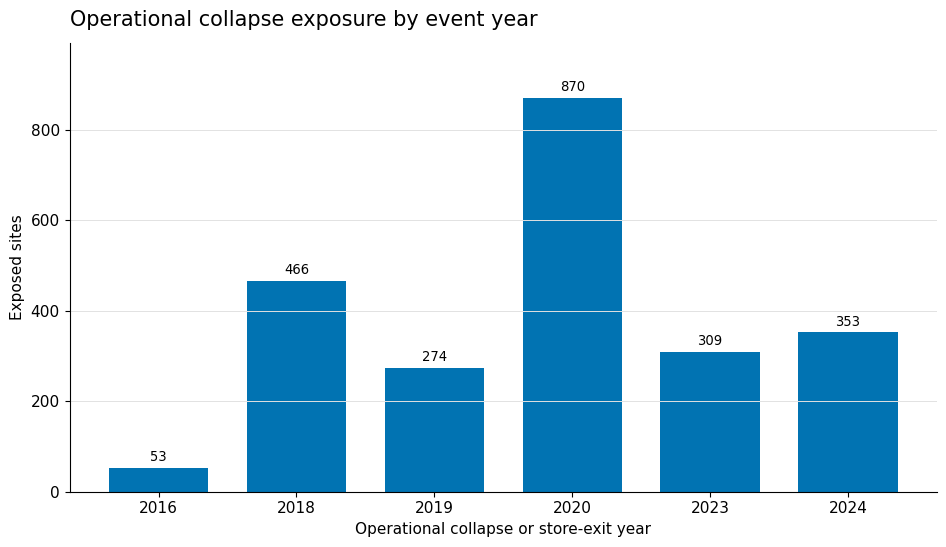

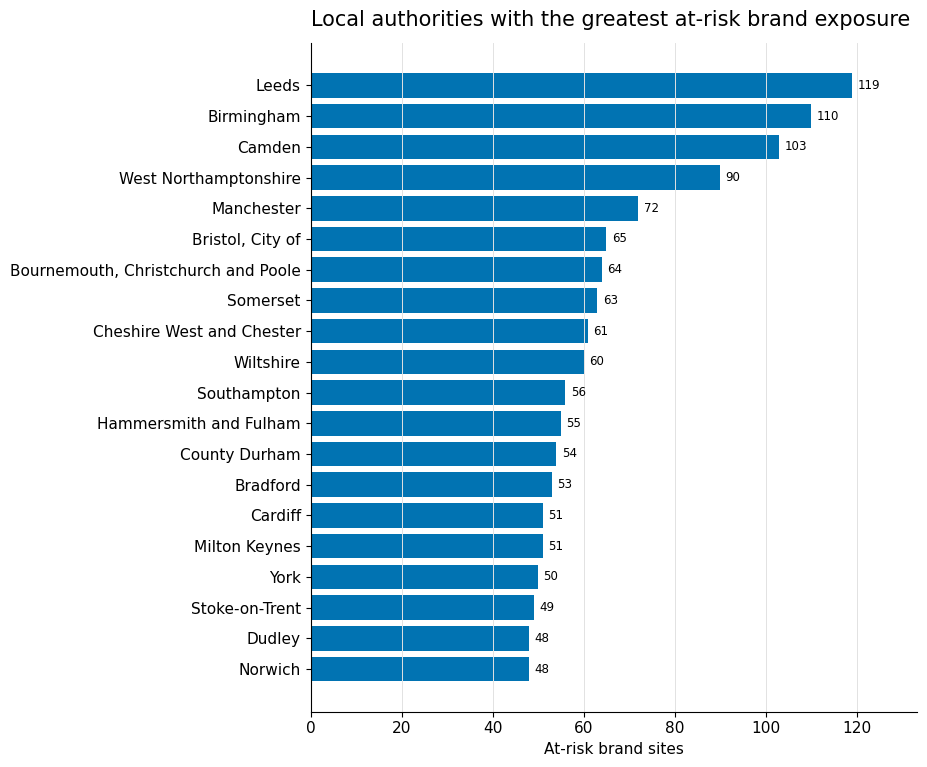

In [22]:
event_counts = (sites.dropna(subset=["event_year"])
                .groupby("event_year")["uarn"].nunique().sort_index())
fig, ax = plt.subplots(figsize=(9.6, 5.6))
bars = ax.bar(event_counts.index.astype(int).astype(str), event_counts.values, color="#0173B2", width=0.72)
for bar, value in zip(bars, event_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 14, f"{value:,}", ha="center", fontsize=9.5)
ax.set_title("Operational collapse exposure by event year", loc="left", pad=12)
ax.set_xlabel("Operational collapse or store-exit year")
ax.set_ylabel("Exposed sites")
ax.set_ylim(0, event_counts.max() * 1.14)
ax.grid(axis="y", color="#E2E2E2", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_OUTPUTS / "figure_4_1_event_year_exposure.png", dpi=300, bbox_inches="tight")
plt.show()

top = authority_coverage.nlargest(20, "at_risk_sites").sort_values("at_risk_sites")
fig, ax = plt.subplots(figsize=(9.4, 7.8))
bars = ax.barh(top["geocode_name"], top["at_risk_sites"], color="#0173B2")
for bar, value in zip(bars, top["at_risk_sites"]):
    ax.text(value + 1.2, bar.get_y() + bar.get_height()/2, f"{int(value)}", va="center", fontsize=8.5)
ax.set_title("Local authorities with the greatest at-risk brand exposure", loc="left", pad=12)
ax.set_xlabel("At-risk brand sites")
ax.set_xlim(0, top["at_risk_sites"].max() * 1.12)
ax.grid(axis="x", color="#E2E2E2", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_OUTPUTS / "figure_4_2_top_authorities.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. H1 matched controls and event-time results

Matched treated: 2,270; controls: 6,810


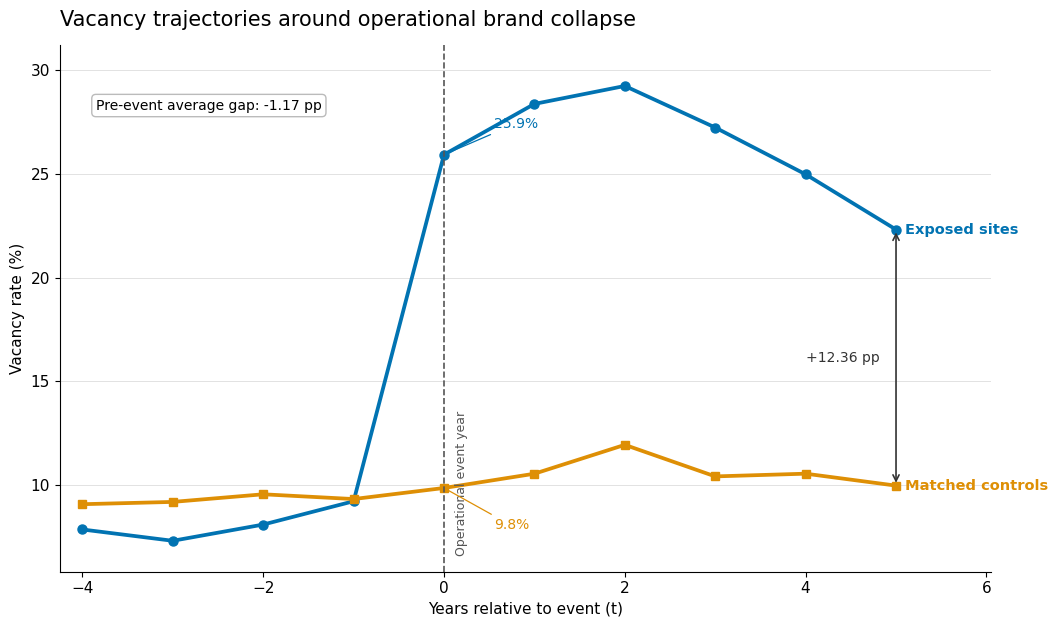

,matched_treated_properties,matched_control_properties,pre_collapse_gap_pp,post_collapse_gap_pp,did_style_difference_pp
0,2270,6810,-1.165793,15.816467,16.982261


,treatment_rate,treatment_n,control_rate,control_n,gap_pp,treatment_pct,control_pct
t,,,,,,,
-4,0.078387,1314,0.090587,3389,-1.220059,7.838661,9.058719
-3,0.072930,1618,0.091693,4177,-1.876306,7.292954,9.169260
-2,0.080764,2043,0.095372,5316,-1.460888,8.076358,9.537246
-1,0.092016,2054,0.093075,5415,-0.105921,9.201558,9.307479
0,0.259296,2017,0.098414,5548,16.088214,25.929598,9.841384
1,0.283777,1991,0.105301,5603,17.847626,28.377700,10.530073
2,0.292442,1720,0.119238,4881,17.320400,29.244186,11.923786
3,0.272377,1296,0.104006,3894,16.837038,27.237654,10.400616
4,0.249796,1225,0.105319,3798,14.447733,24.979592,10.531859


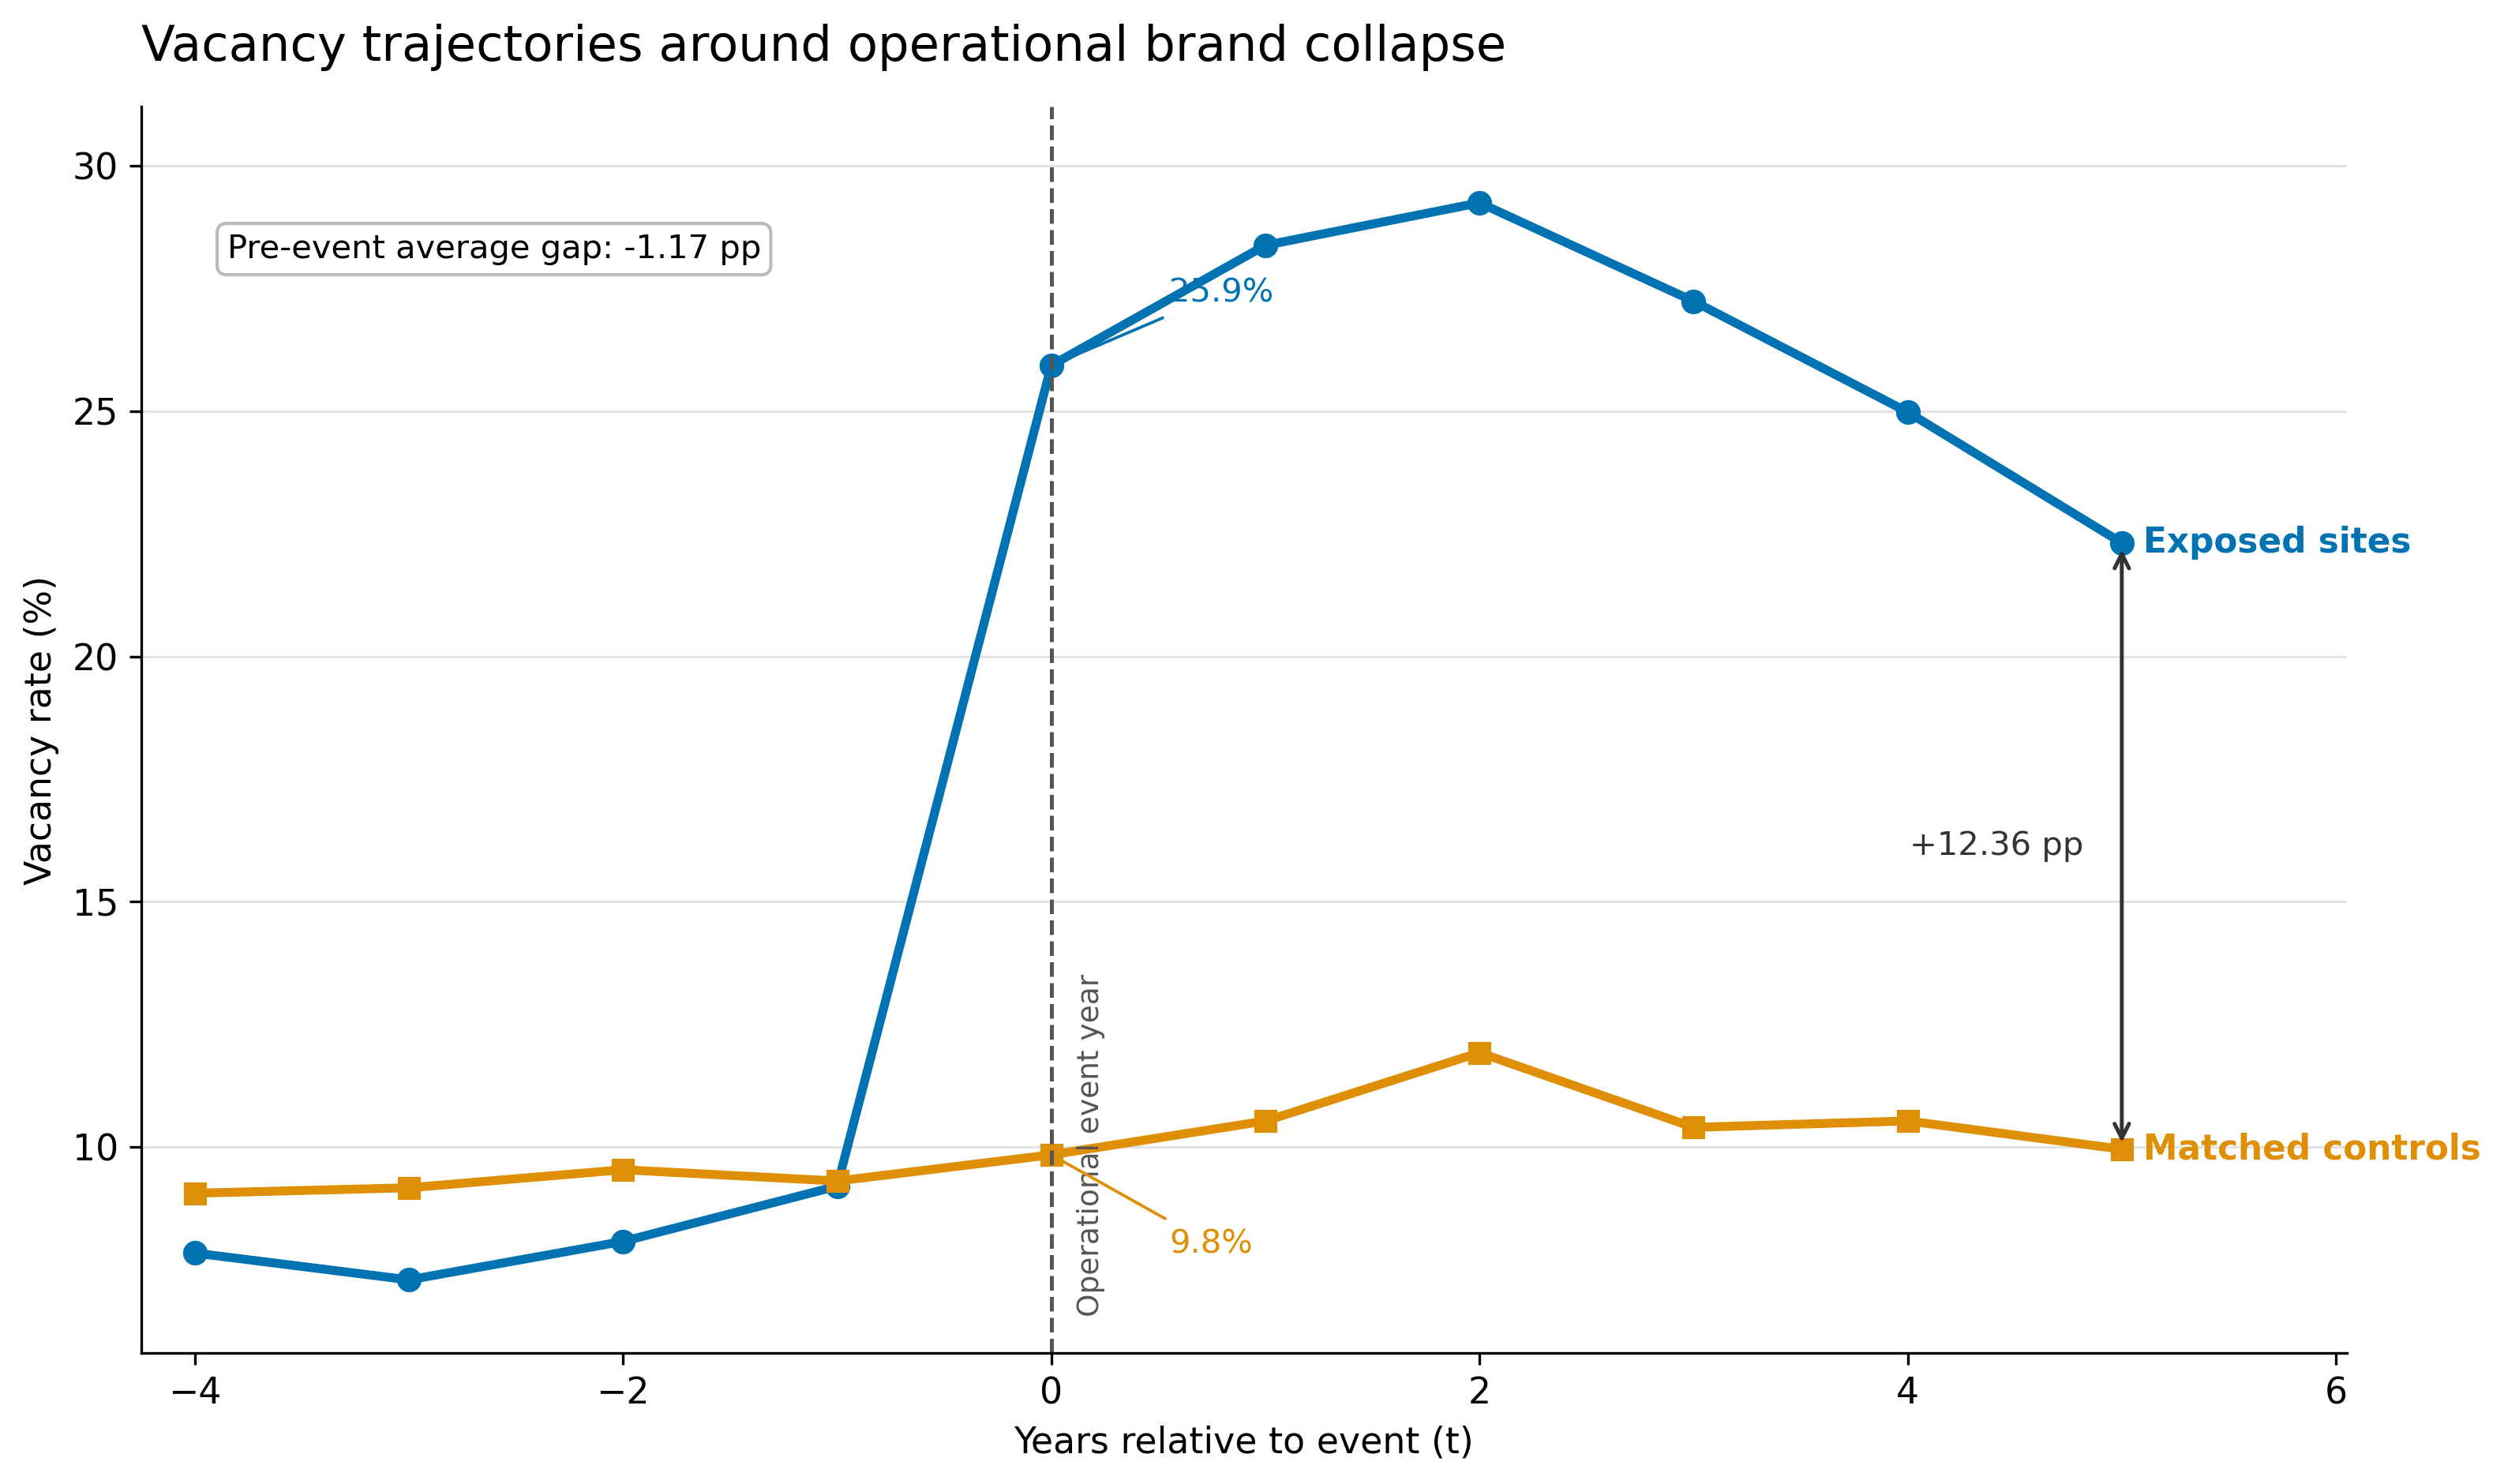

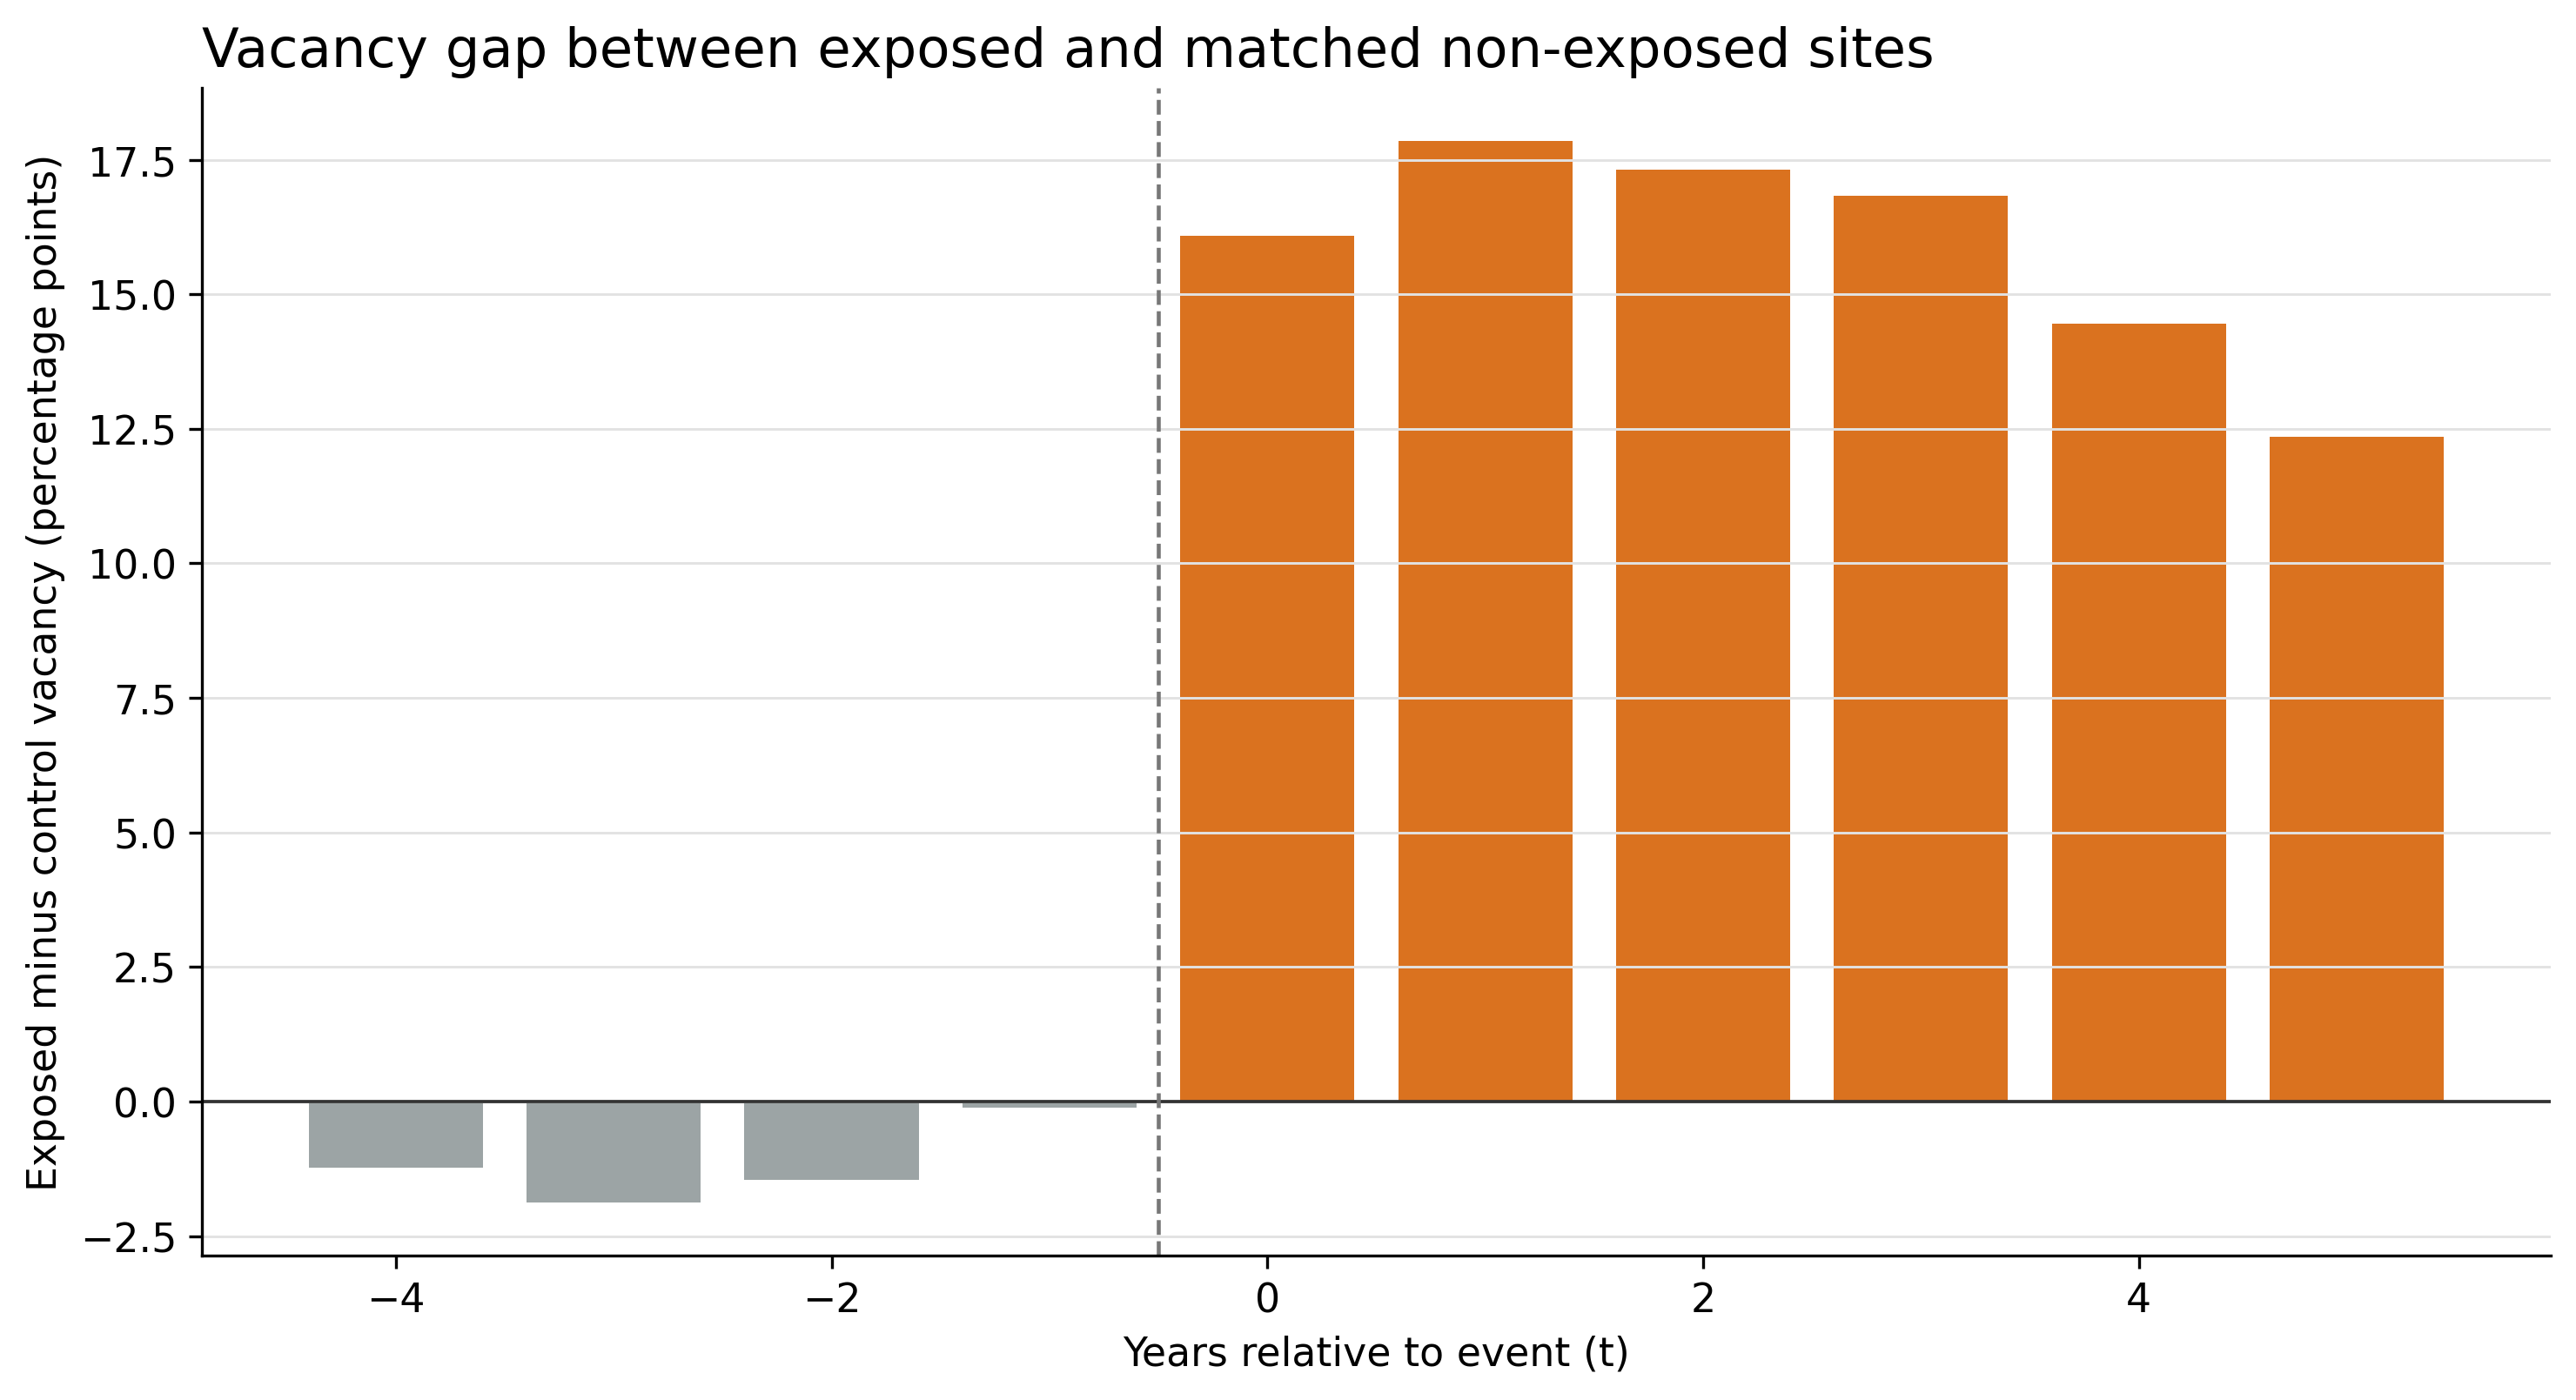

In [23]:
matches = match_controls(df, brand_by_uarn, tainted)
print(f"Matched treated: {matches['treat_uarn'].nunique():,}; controls: {matches['control_uarn'].nunique():,}")
curves = h1_event_study(df, brand_by_uarn, matches)
display(pd.read_csv(BASE / "finding_2_h1_event_study_summary.csv"))
display(curves)

display(Image(filename=str(OUT / 'finding_2_h1_event_study.png')))
display(Image(filename=str(OUT / 'finding_2_h1_gap_by_event_time.png')))

## 8. H1 spatial illustration
This map shows where Camden's exposed properties and matched controls are located. It illustrates the comparison design and is not an effect map.

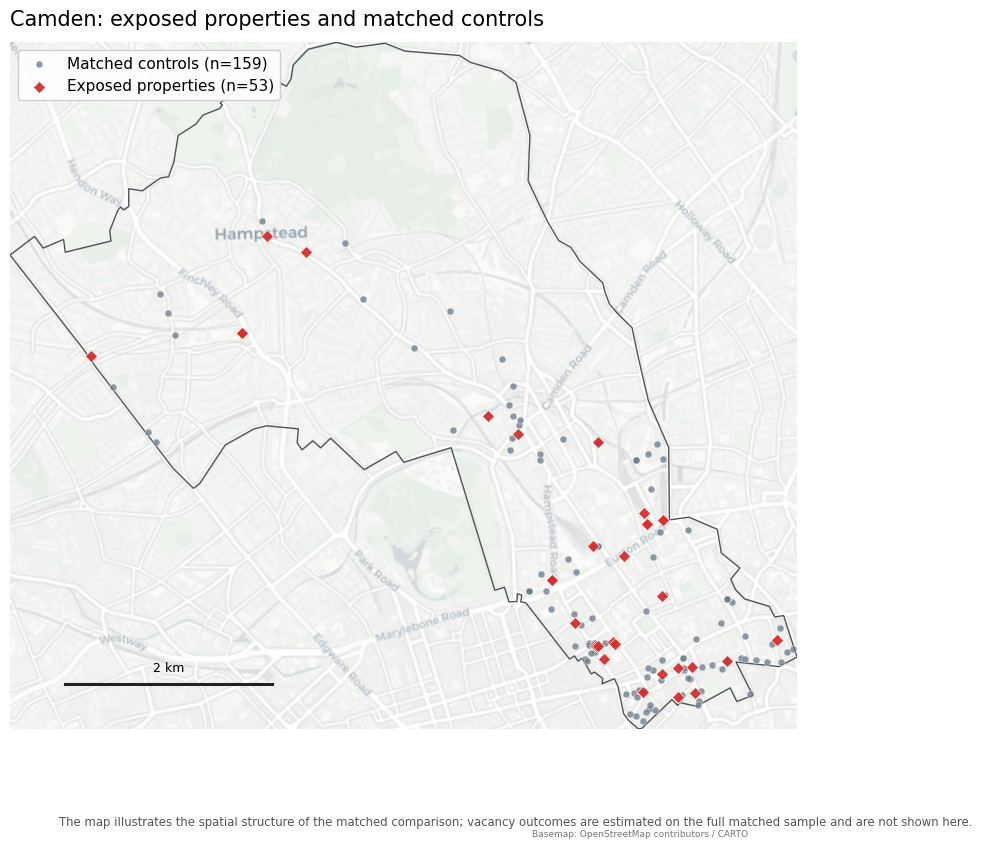

Saved: /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/outputs/publication_figures/main_map_h1_camden_matched_locations.png


In [24]:
authority = "Camden"
city_matches = matches[matches["geocode_name"].eq(authority)].copy()

treated = (city_matches[["treat_uarn"]].drop_duplicates()
           .rename(columns={"treat_uarn": "uarn"}))
controls = (city_matches[["control_uarn"]].drop_duplicates()
            .rename(columns={"control_uarn": "uarn"}))
treated["group"] = "Exposed property"
controls["group"] = "Matched control"
map_properties = pd.concat([treated, controls], ignore_index=True)

geometry = (df[df["uarn"].isin(map_properties["uarn"])]
            .sort_values(["uarn", "year"])
            .drop_duplicates("uarn")[["uarn", "geometry"]])
geometry["geometry"] = geometry["geometry"].apply(wkb_to_geometry)
points = map_properties.merge(geometry, on="uarn", how="left")
points = gpd.GeoDataFrame(points, geometry="geometry", crs="EPSG:4326")
points = points[points.geometry.notna()].to_crs("EPSG:27700")

with LAD_BOUNDARIES.open(encoding="utf-8") as stream:
    lads_json = json.load(stream)
lads = gpd.GeoDataFrame.from_features(
    lads_json["features"], crs="EPSG:4326"
).to_crs("EPSG:27700")
name_col = next(c for c in ["LAD24NM", "LAD23NM", "LAD22NM", "LAD21NM", "LADNM", "NAME"] if c in lads.columns)
boundary = lads[lads[name_col].eq(authority)]

fig, ax = plt.subplots(figsize=(8.2, 8.8))
minx, miny, maxx, maxy = boundary.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

try:
    import contextily as ctx
    ctx.add_basemap(ax, crs=boundary.crs, source=ctx.providers.CartoDB.Positron,
                    attribution=False, reset_extent=True)
    boundary.boundary.plot(ax=ax, color="#4E5358", linewidth=1.0, zorder=2)
except Exception as exc:
    print("Basemap unavailable; using LAD outline only:", exc)
    boundary.plot(ax=ax, color="#F5F5F3", edgecolor="#4E5358", linewidth=1.0, zorder=1)

control_points = points[points["group"].eq("Matched control")]
exposed_points = points[points["group"].eq("Exposed property")]
control_points.plot(ax=ax, color="#6F7D8C", marker="o", markersize=25,
                    edgecolor="white", linewidth=0.35, alpha=0.78, zorder=3,
                    label=f"Matched controls (n={control_points['uarn'].nunique():,})")
exposed_points.plot(ax=ax, color="#D62F2F", marker="D", markersize=38,
                    edgecolor="white", linewidth=0.45, alpha=0.95, zorder=4,
                    label=f"Exposed properties (n={exposed_points['uarn'].nunique():,})")

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
x = minx + 0.07 * (maxx - minx)
y = miny + 0.065 * (maxy - miny)
ax.plot([x, x + 2000], [y, y], color="#222222", linewidth=2.2, zorder=5)
ax.text(x + 1000, y + 0.018 * (maxy - miny), "2 km", ha="center", fontsize=9)

ax.set_title("Camden: exposed properties and matched controls", loc="left", fontsize=15, pad=12)
ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.92)
ax.set_axis_off()
fig.text(0.08, 0.025,
         "The map illustrates the spatial structure of the matched comparison; vacancy outcomes are estimated on the full matched sample and are not shown here.",
         fontsize=8.4, color="#555555")
fig.text(0.92, 0.012, "Basemap: OpenStreetMap contributors / CARTO",
         ha="right", fontsize=6.5, color="#777777")
fig.tight_layout(rect=[0, 0.05, 1, 1])
output = FIGURE_OUTPUTS / "main_map_h1_camden_matched_locations.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)

## 9. H1 control-distance robustness

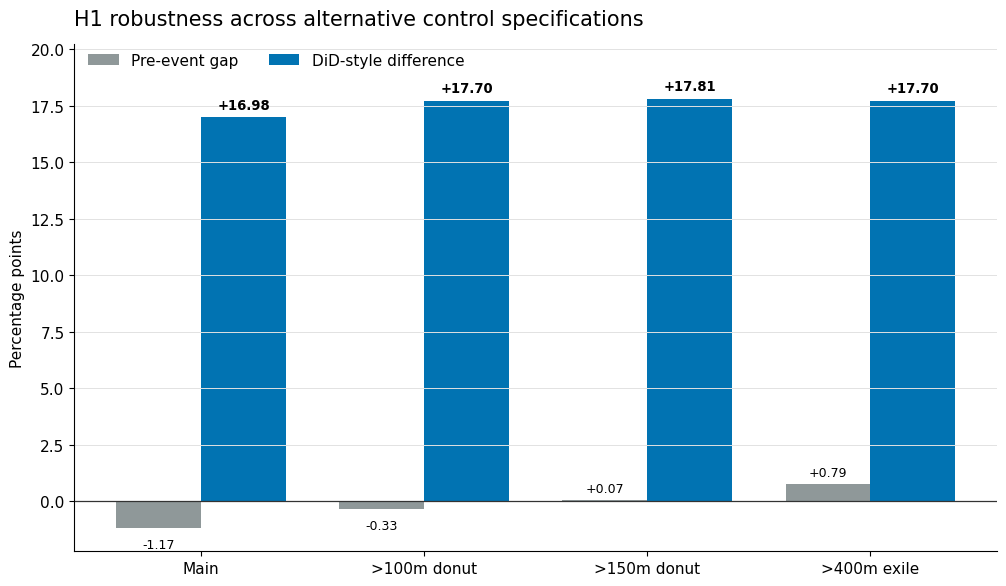

,specification,matched_treated_properties,matched_control_properties,pre_collapse_gap_pp,post_collapse_gap_pp,did_style_difference_pp
0,main_matched,2270,6810,-1.165793,15.816467,16.982261
1,donut_gt_100m,2270,6810,-0.330605,17.367615,17.698220
2,donut_gt_150m,2270,6810,0.067193,17.874033,17.806840
3,exile_gt_400m,2270,6810,0.790045,18.491476,17.701431


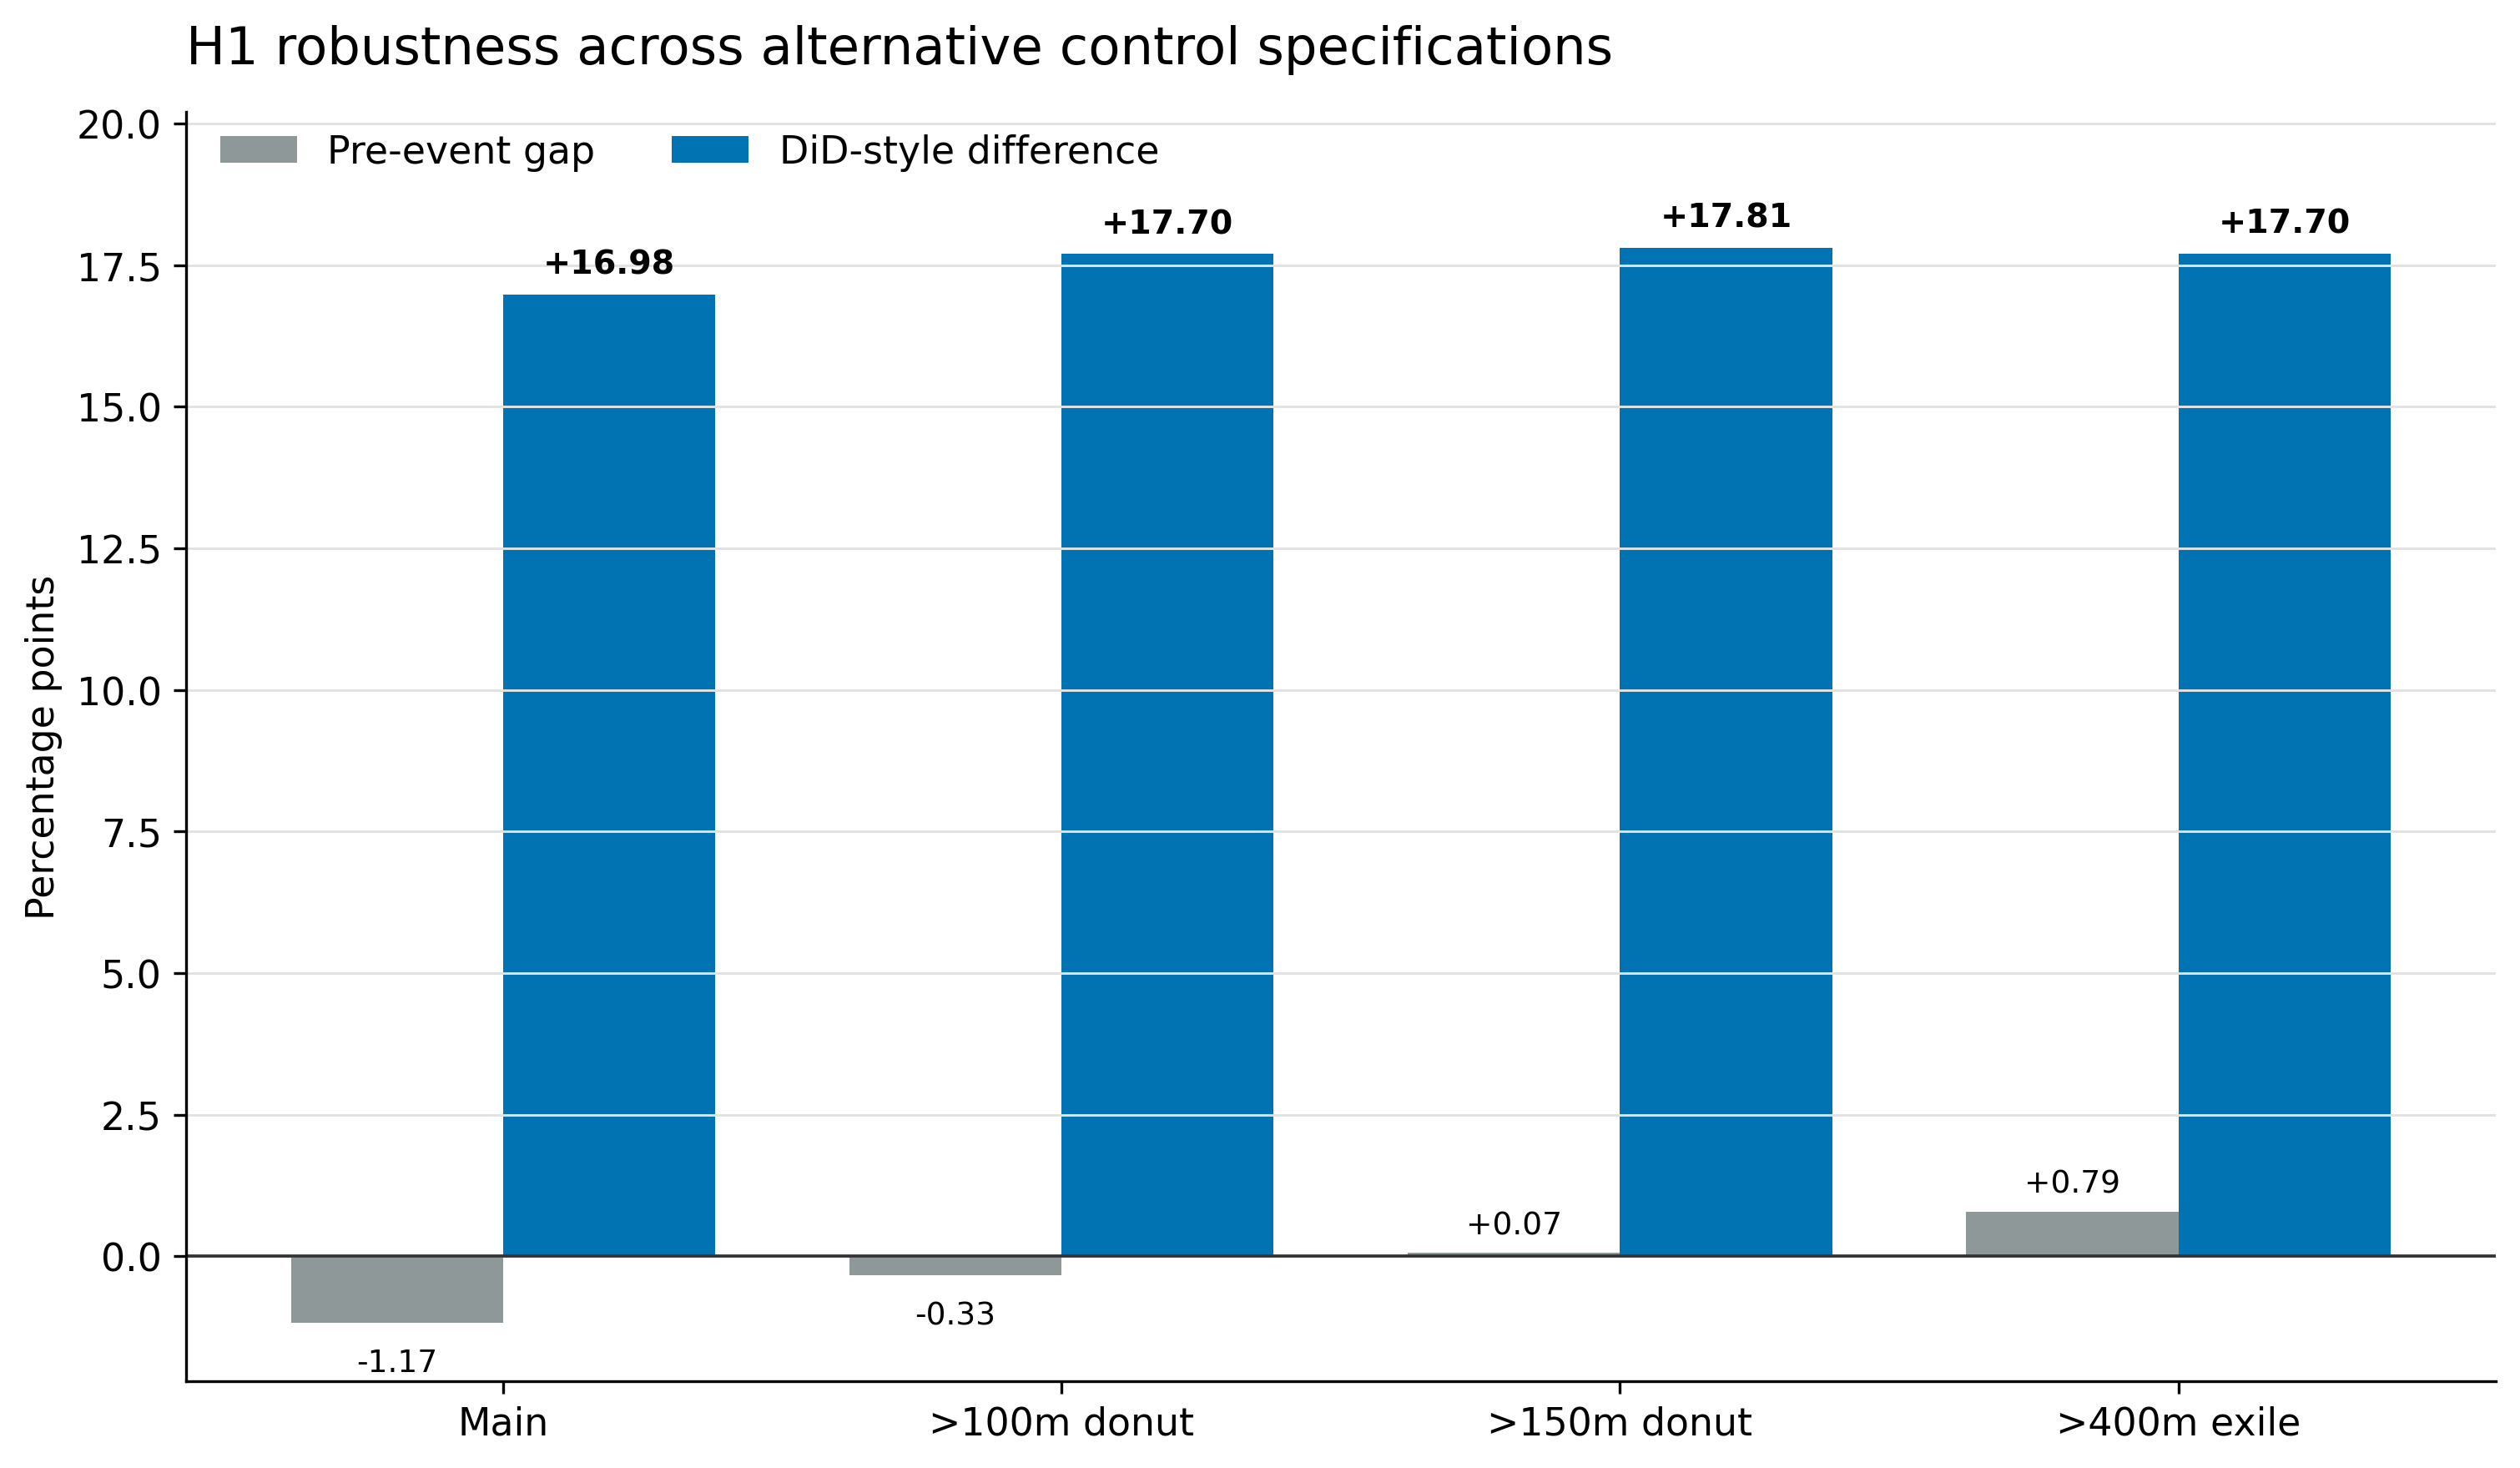

In [25]:
h1_donut_robustness(df, brand_by_uarn, tainted, sites, matches)
robust = pd.read_csv(BASE / "finding_2_h1_donut_robustness_summary.csv")
display(robust)

display(Image(filename=str(OUT / 'finding_2_h1_donut_robustness.png')))

## 10. H3 clustered versus isolated sites

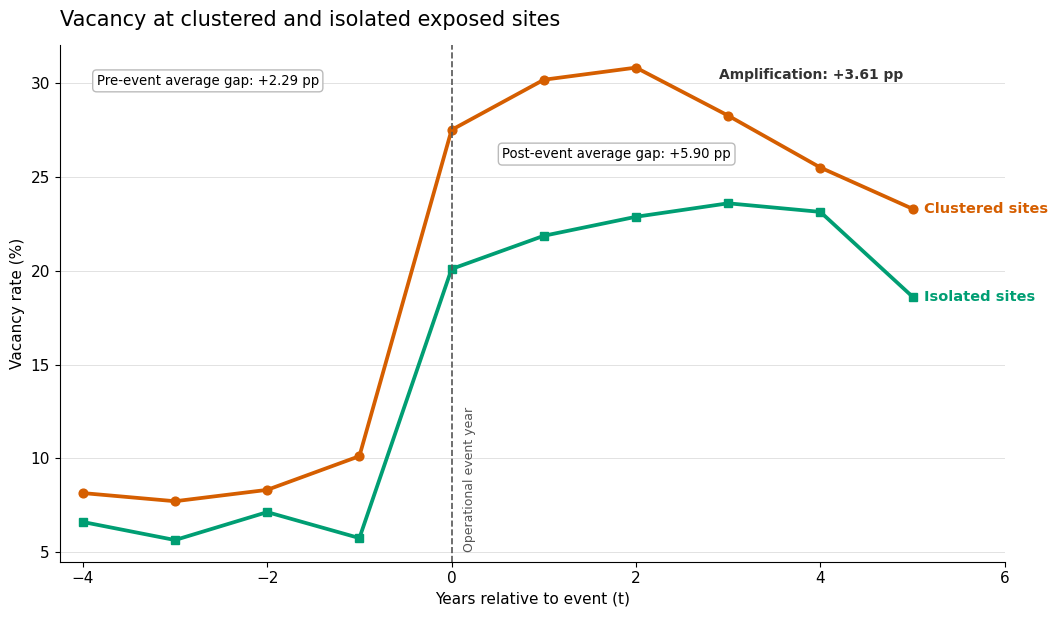

,clustered_treated_properties,isolated_treated_properties,pre_clustered_minus_isolated_pp,post_clustered_minus_isolated_pp,cluster_amplification_pp
0,1773,497,2.288919,5.896916,3.607998


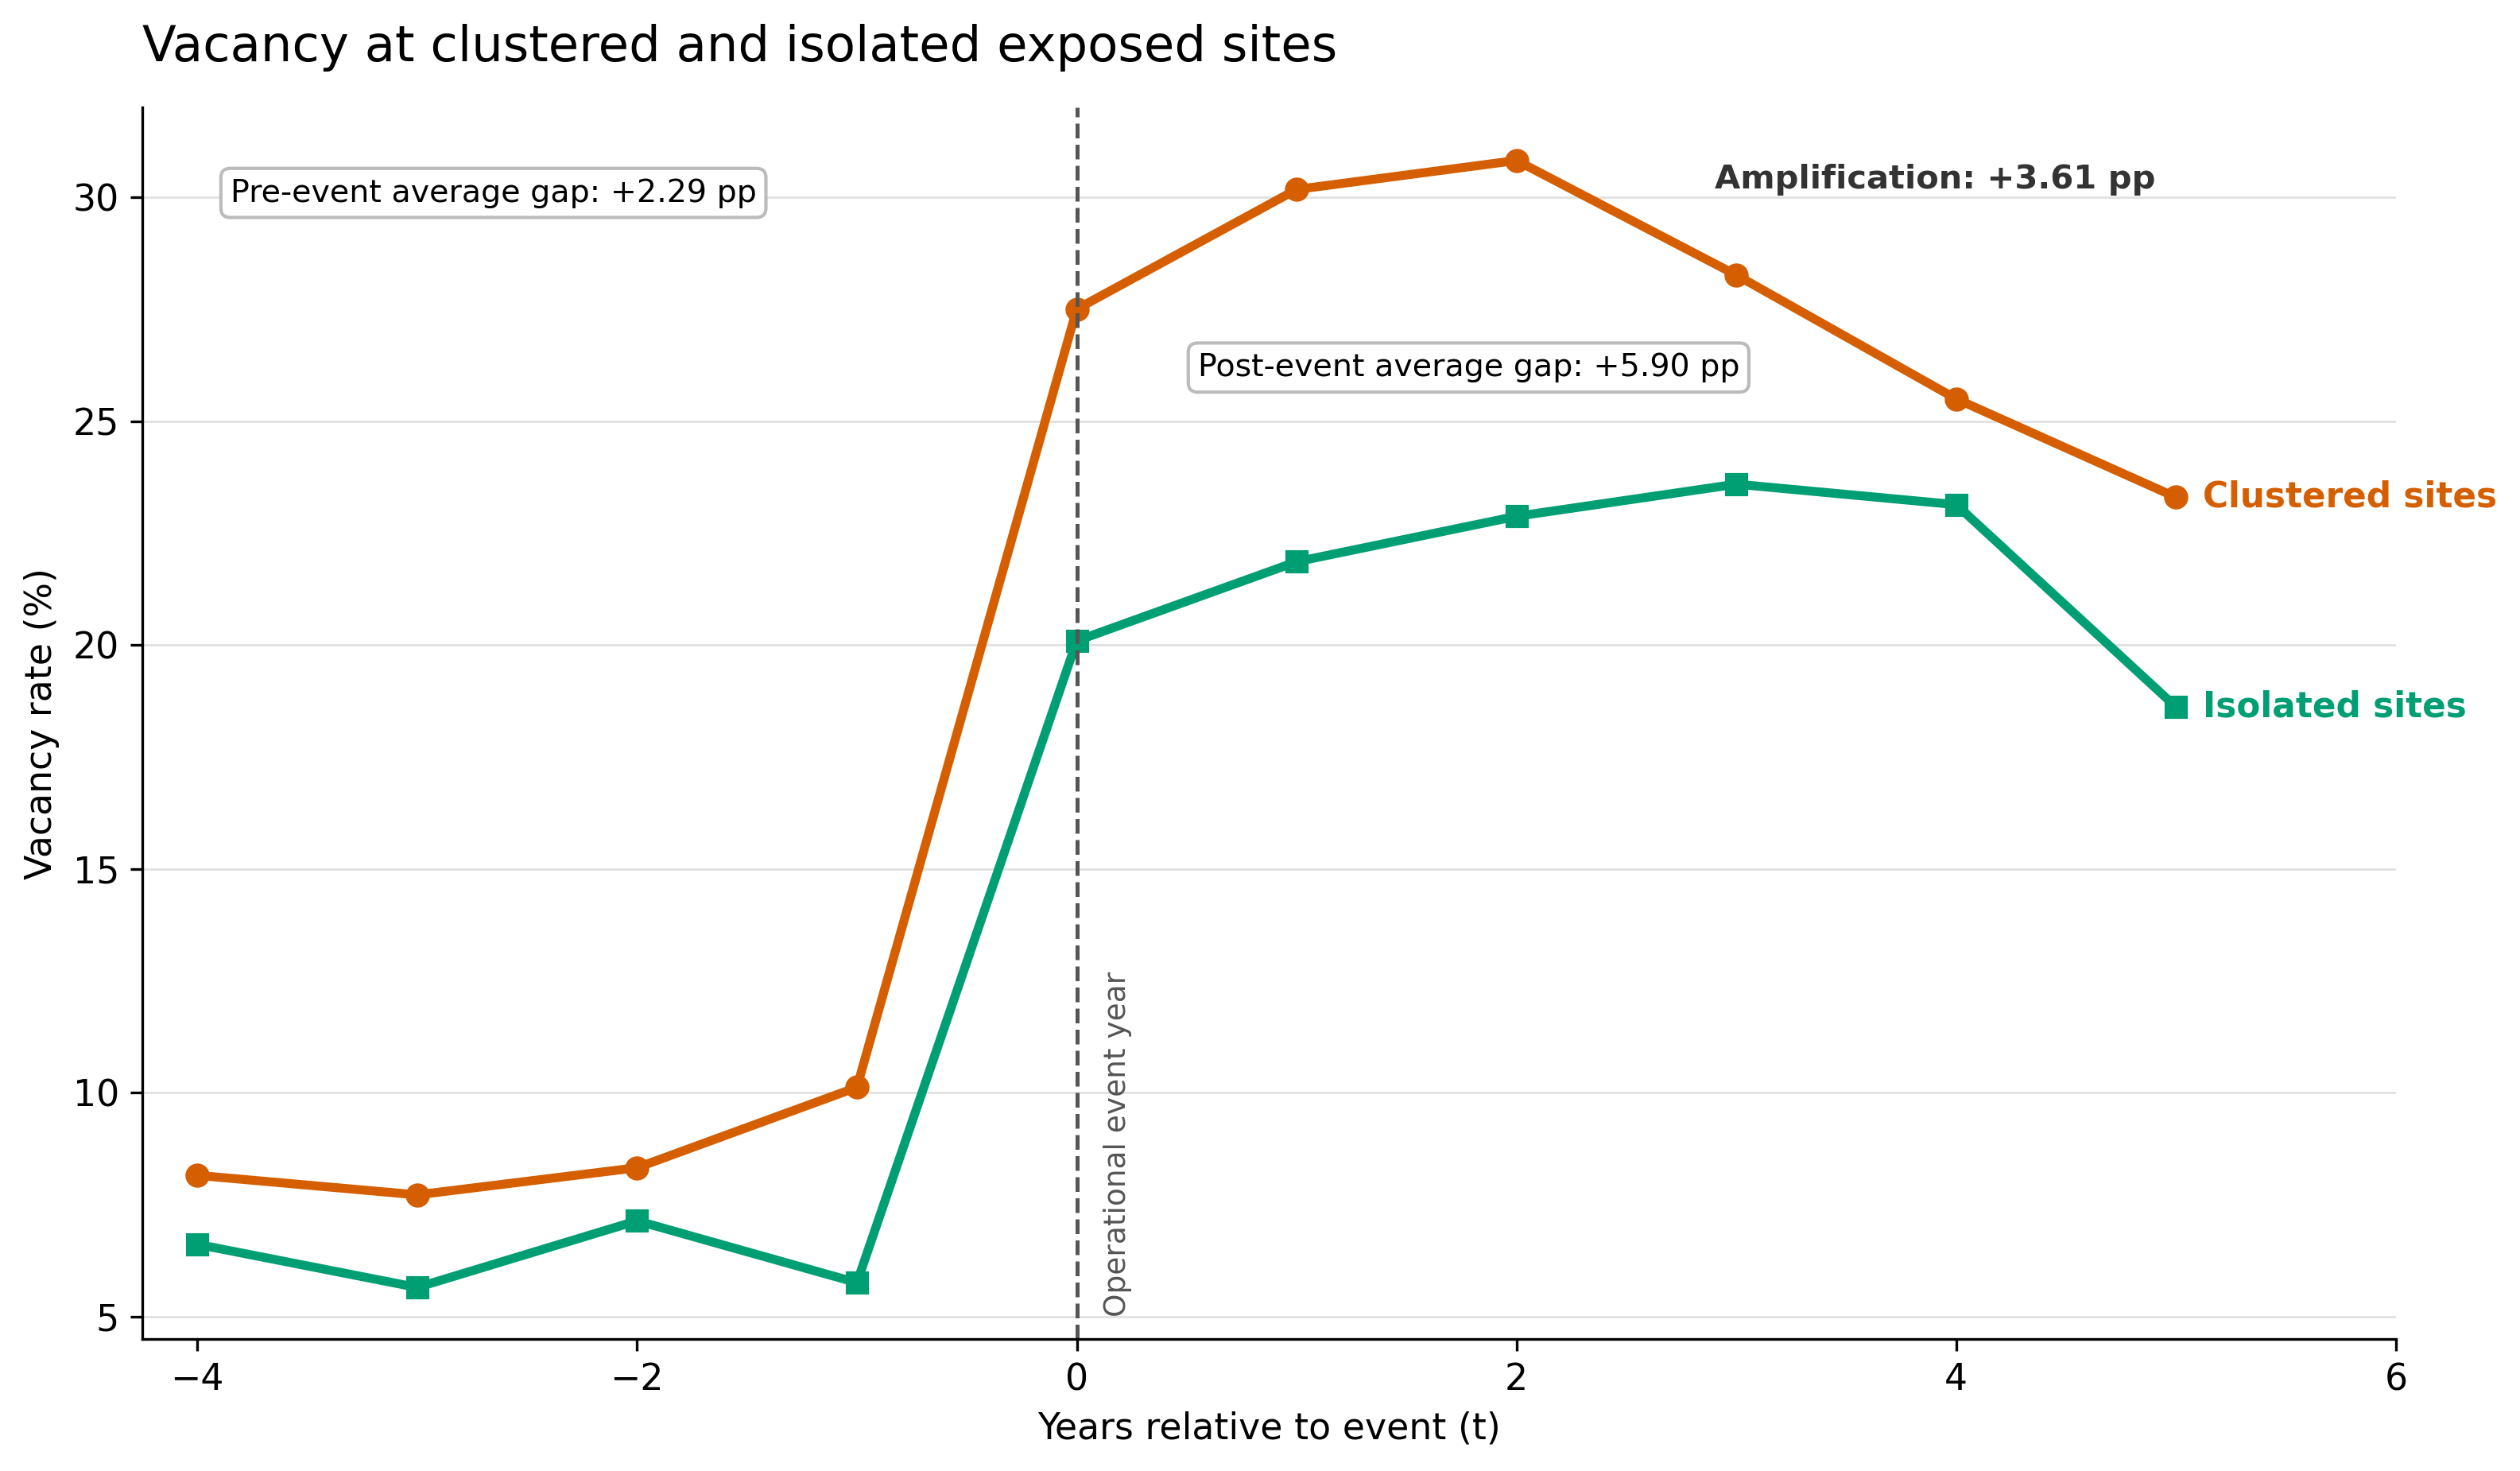

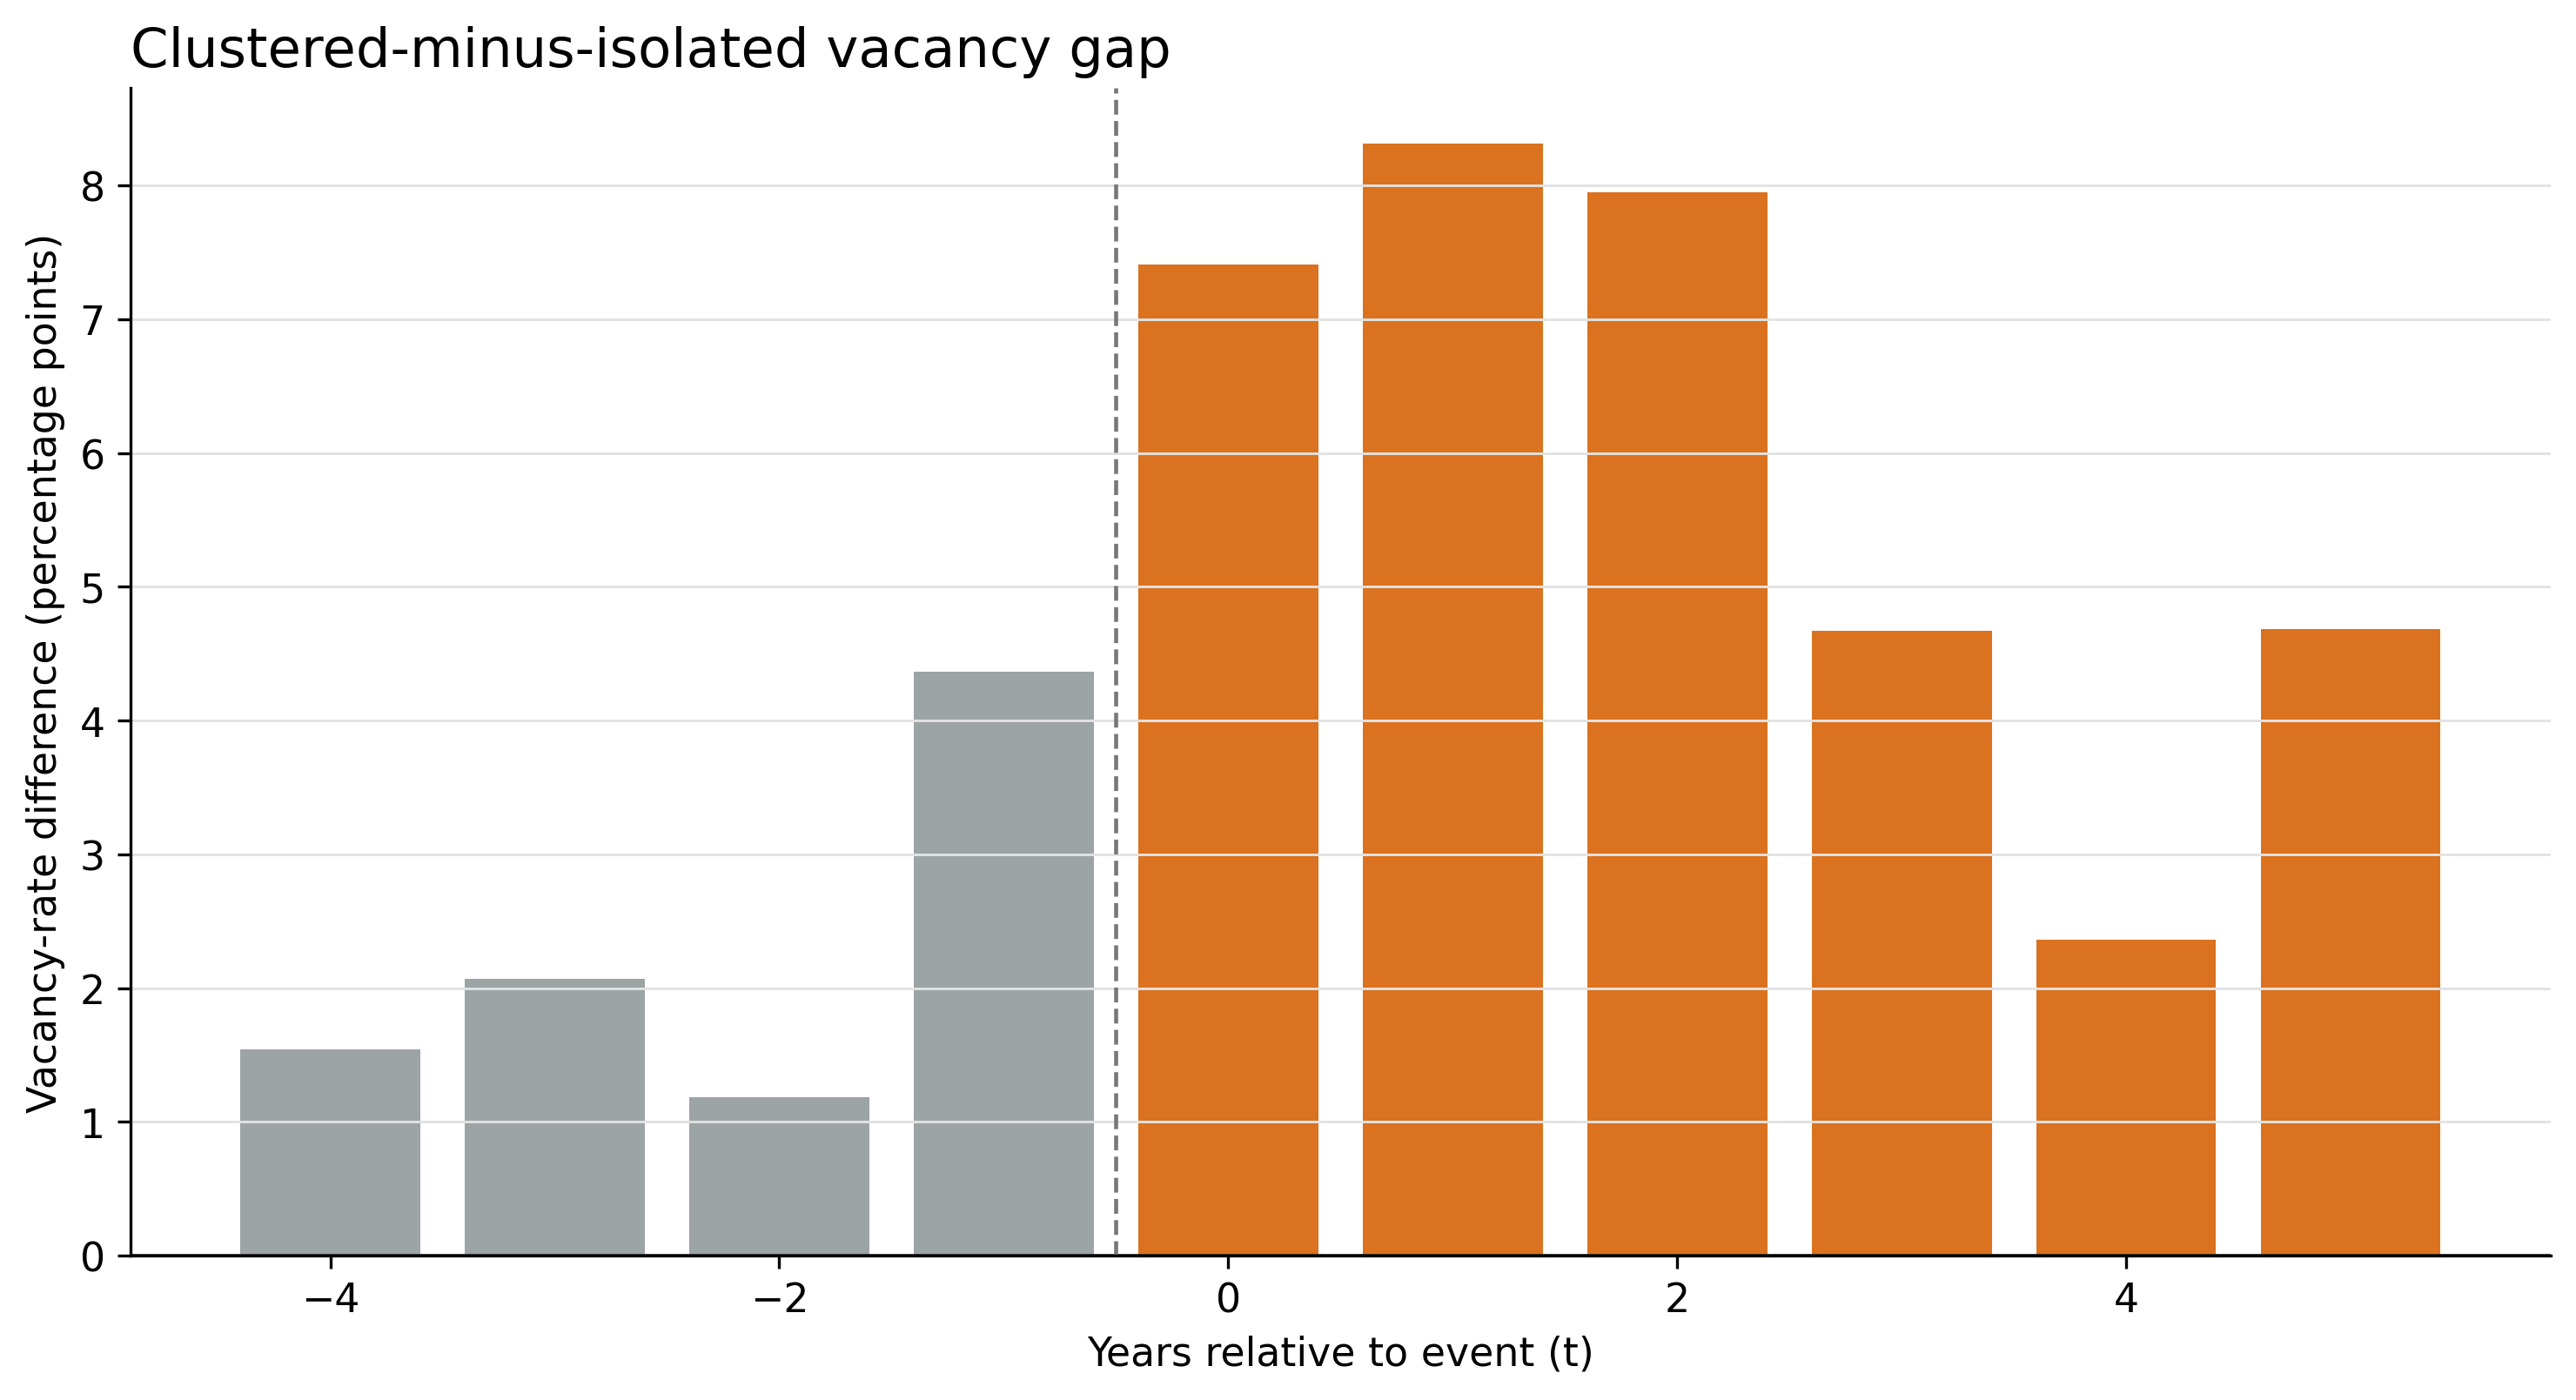

In [26]:
h3_clustered_vs_isolated(df, sites, matches)
display(pd.read_csv(BASE / "finding_4_h3_clustered_vs_isolated_summary.csv"))

display(Image(filename=str(OUT / 'finding_4_h3_clustered_vs_isolated.png')))
display(Image(filename=str(OUT / 'finding_4_h3_cluster_gap_by_event_time.png')))

## 11. H3 distance-threshold sensitivity

In [27]:
h3_sensitivity = pd.DataFrame([
    h3_summary_at_radius(df, sites, matches, radius)
    for radius in SENSITIVITY_EPS
])
h3_sensitivity.to_csv(OUT / "finding_4_h3_threshold_sensitivity.csv", index=False)
display(h3_sensitivity)

,radius_m,clustered_treated,isolated_treated,pre_gap_pp,post_gap_pp,amplification_pp
0,250,1668,602,2.172215,6.366034,4.193819
1,400,1773,497,2.288919,5.896916,3.607998
2,800,1930,340,3.138743,7.418511,4.279768


## 12. H3 property composition

Rateable value is taken from the treated value used by the matching routine.
Property-category shares use the same 2,270 matched treated properties.


In [28]:
treated_composition = (matches.drop_duplicates("treat_uarn")
                       [["treat_uarn", "treated_rateable_value", "category_subgroup"]]
                       .merge(sites[["uarn", "clustered"]].drop_duplicates("uarn"),
                              left_on="treat_uarn", right_on="uarn", how="left"))
treated_composition["group"] = np.where(
    treated_composition["clustered"].fillna(False), "Clustered", "Isolated"
)

composition_rows = []
for group, sub in treated_composition.groupby("group"):
    shares = sub["category_subgroup"].value_counts(normalize=True)
    composition_rows.append({
        "group": group,
        "treated_properties": sub["treat_uarn"].nunique(),
        "median_matching_rateable_value": sub["treated_rateable_value"].median(),
        "high_street_retail_pct": shares.get("RETAIL_HIGH_STREET", 0) * 100,
        "industrial_general_pct": shares.get("INDUSTRIAL_GENERAL", 0) * 100,
    })

h3_composition = pd.DataFrame(composition_rows)
h3_composition.to_csv(OUT / "finding_4_h3_property_composition.csv", index=False)
display(h3_composition)


,group,treated_properties,median_matching_rateable_value,high_street_retail_pct,industrial_general_pct
0,Clustered,1773,93000.0,47.546531,1.240835
1,Isolated,497,37250.0,24.346076,17.505030


## 13. Brand-level heterogeneity

These five externally selected examples reproduce Figure 5.1. They illustrate
contrasting trajectories and are not a separate hypothesis test.


,brand,t,vacancy_rate,n,vacancy_pct,brand_display,trajectory_type
0,body shop,-4,0.061111,180,6.111111,The Body Shop,Near-null
1,body shop,-3,0.067039,179,6.703911,The Body Shop,Near-null
2,body shop,-2,0.061453,179,6.145251,The Body Shop,Near-null
3,body shop,-1,0.060976,164,6.097561,The Body Shop,Near-null
4,body shop,0,0.068027,147,6.802721,The Body Shop,Near-null
5,body shop,1,0.076923,143,7.692308,The Body Shop,Near-null
6,debenhams,-4,0.009901,101,0.990099,Debenhams,Persistent
7,debenhams,-3,0.009804,102,0.980392,Debenhams,Persistent
8,debenhams,-2,0.009346,107,0.934579,Debenhams,Persistent
9,debenhams,-1,0.027523,109,2.752294,Debenhams,Persistent


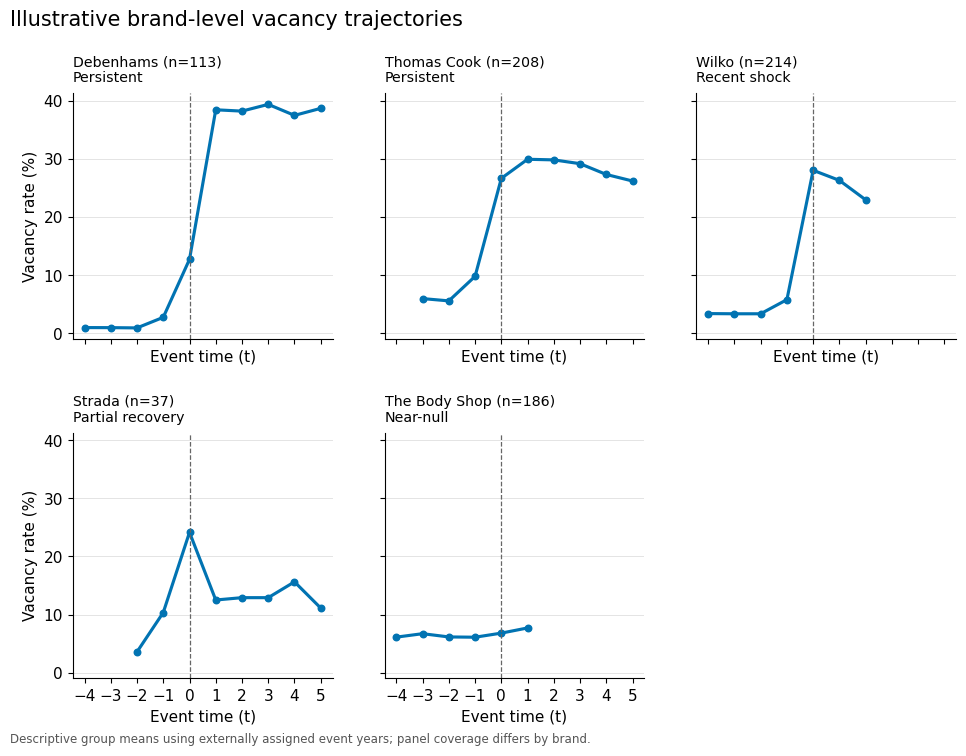

In [29]:
selected_brands = ["debenhams", "thomas cook", "wilko", "strada", "body shop"]
display_names = {"debenhams": "Debenhams", "thomas cook": "Thomas Cook", "wilko": "Wilko",
                 "strada": "Strada", "body shop": "The Body Shop"}
trajectory_types = {"debenhams": "Persistent", "thomas cook": "Persistent",
                    "wilko": "Recent shock", "strada": "Partial recovery", "body shop": "Near-null"}
brand_meta = brand_by_uarn[brand_by_uarn.isin(selected_brands)].rename("brand").to_frame()
brand_meta["event_year"] = brand_meta["brand"].map(OPERATIONAL_EVENT_YEAR)
brand_records = (df[df["uarn"].isin(brand_meta.index)][["uarn", "year", "occupation_state"]]
                 .merge(brand_meta, left_on="uarn", right_index=True))
brand_records["t"] = brand_records["year"] - brand_records["event_year"]
brand_records = brand_records[brand_records["t"].between(EVENT_MIN, EVENT_MAX)
                              & brand_records["occupation_state"].notna()].copy()
brand_records["vacant"] = brand_records["occupation_state"].eq("VACANT")
brand_curves = brand_records.groupby(["brand", "t"])["vacant"].agg(vacancy_rate="mean", n="count").reset_index()
brand_curves["vacancy_pct"] = brand_curves["vacancy_rate"] * 100
brand_curves["brand_display"] = brand_curves["brand"].map(display_names)
brand_curves["trajectory_type"] = brand_curves["brand"].map(trajectory_types)
brand_curves.to_csv(FIGURE_OUTPUTS / "figure_5_1_brand_heterogeneity_curves.csv", index=False)
display(brand_curves)

fig, axes = plt.subplots(2, 3, figsize=(11.4, 7.6), sharex=True, sharey=True)
for ax, brand in zip(axes.flat, selected_brands):
    sub = brand_curves[brand_curves["brand"].eq(brand)].sort_values("t")
    ax.plot(sub["t"], sub["vacancy_pct"], color="#0173B2", marker="o", ms=4.7, lw=2.25)
    ax.axvline(0, color="#666666", ls="--", lw=0.9)
    site_n = brand_meta[brand_meta["brand"].eq(brand)].index.nunique()
    ax.set_title(f"{display_names[brand]} (n={site_n})\n{trajectory_types[brand]}",
                 loc="left", fontsize=10.2, pad=8)
    ax.set_xticks(range(EVENT_MIN, EVENT_MAX + 1))
    ax.grid(axis="y", color="#E2E2E2", linewidth=0.65)
    ax.spines[["top", "right"]].set_visible(False)
axes.flat[-1].set_visible(False)
for ax in axes[0, :]:
    if ax.get_visible():
        ax.set_xlabel("Event time (t)")
for ax in axes[1, :2]:
    ax.set_xlabel("Event time (t)")
for ax in axes[:, 0]:
    ax.set_ylabel("Vacancy rate (%)")
fig.suptitle("Illustrative brand-level vacancy trajectories", x=0.07, ha="left", fontsize=15)
fig.text(0.07, 0.015, "Descriptive group means using externally assigned event years; panel coverage differs by brand.",
         fontsize=8.5, color="#555555")
fig.subplots_adjust(top=0.87, bottom=0.10, hspace=0.38, wspace=0.20)
fig.savefig(FIGURE_OUTPUTS / "figure_5_1_brand_heterogeneity_small_multiples.png",
            dpi=300, bbox_inches="tight")
plt.show()


## 14. Final tables


In [30]:
display(pd.read_csv(OUT / "finding_2_h1_event_study_summary.csv"))
display(pd.read_csv(OUT / "finding_2_h1_donut_robustness_summary.csv"))
display(pd.read_csv(OUT / "finding_4_h3_clustered_vs_isolated_summary.csv"))
display(pd.read_csv(OUT / "finding_4_h3_threshold_sensitivity.csv"))

,matched_treated_properties,matched_control_properties,pre_collapse_gap_pp,post_collapse_gap_pp,did_style_difference_pp
0,2270,6810,-1.165793,15.816467,16.982261


,specification,matched_treated_properties,matched_control_properties,pre_collapse_gap_pp,post_collapse_gap_pp,did_style_difference_pp
0,main_matched,2270,6810,-1.165793,15.816467,16.982261
1,donut_gt_100m,2270,6810,-0.330605,17.367615,17.698220
2,donut_gt_150m,2270,6810,0.067193,17.874033,17.806840
3,exile_gt_400m,2270,6810,0.790045,18.491476,17.701431


,clustered_treated_properties,isolated_treated_properties,pre_clustered_minus_isolated_pp,post_clustered_minus_isolated_pp,cluster_amplification_pp
0,1773,497,2.288919,5.896916,3.607998


,radius_m,clustered_treated,isolated_treated,pre_gap_pp,post_gap_pp,amplification_pp
0,250,1668,602,2.172215,6.366034,4.193819
1,400,1773,497,2.288919,5.896916,3.607998
2,800,1930,340,3.138743,7.418511,4.279768
